<img src = "https://drive.google.com/uc?export=view&id=1rSrsZ04aJ_D3BC67Cy2dBUZ6tmguydNf" alt = "Encabezado MLDS" width = "100%">  </img>

# **Preparación de los datos**
---

Este notebook es una plantilla que le puede servir como guía para el tercer entregable del proyecto aplicado.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. ---**INGRESE SU RESPUESTA**---
2. ---**Brayan Sebastian Yepes Garcia**---
3. ---**INGRESE SU RESPUESTA**---

# ICARE

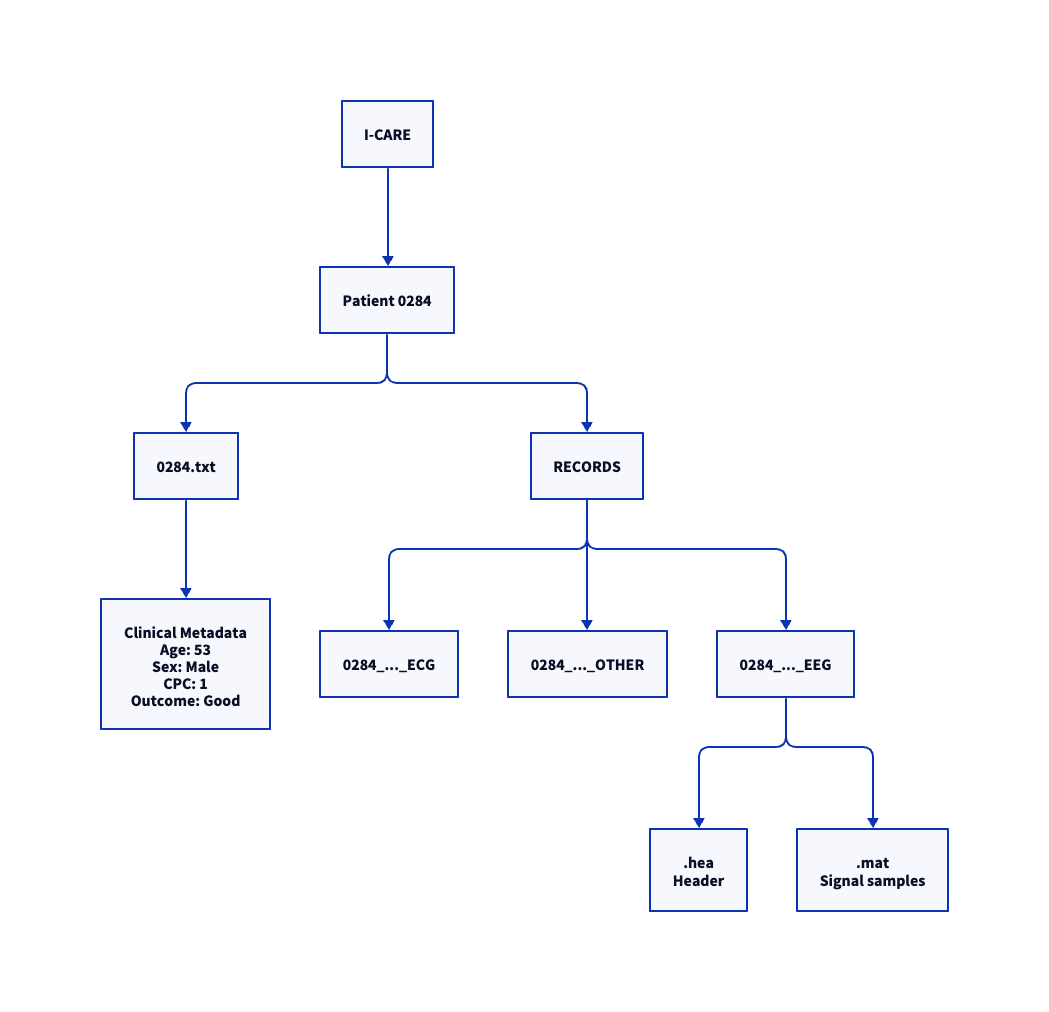

# Clinical

## **1. Limpieza de los Datos**
---

La elección de las técnicas de preprocesamiento puede diferir en cada conjunto de datos. Recuerde que es posible aplicar, según sea necesario (no necesariamente todas), las técnicas generales que se han explorado en el curso. La elección dependerá del tipo de datos con el que esté trabajando.

A lo largo de esta entrega, busque responder las siguientes preguntas:

- ¿Cuáles fueron los criterios utilizados para identificar y tratar valores atípicos, datos faltantes o cualquier otra anomalía en el conjunto de datos durante el proceso de limpieza?
- ¿Cómo se justificaría la necesidad de cada paso de preprocesamiento en términos de mejora de la calidad de los datos y preparación para el análisis subsiguiente?

A continuación encontrará los puntos a tratar a medida que va realizando la preparación de los datos. En cada punto defina el estado en que se encontraba el dataset, ademas de explicar y justificar las acciones y decisiones que se tomaron.

### **1.1. Valores faltantes**
---
Al encontrarnos con valores faltantes en el conjunto de datos, es crucial preguntarse:
* ¿Cómo afectan estos valores a la integridad y representatividad de la información?
* ¿Cómo se identificaron los valores faltantes en el conjunto de datos?
* ¿Cuáles fueron los criterios para decidir si rellenar con valores estimados o eliminar los valores faltantes? En caso que aplique, ¿qué método de relleno se utilizó y por qué se consideró apropiado?
* ¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave? Por ejemplo, si hay valores faltantes en una variable crítica, ¿cómo podría afectar la interpretación de los resultados?

In [1]:
import urllib3
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [3]:
BASE_URL = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"

# Sesión con reintentos automáticos para errores transitorios del servidor
# (502/503/504) y fallos de conexión, en vez de que todo el proceso se caiga
# por un solo paciente como pasó con el 0419.
session = requests.Session()
retries = Retry(
    total=5,
    backoff_factor=1.5,
    status_forcelist=[502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retries))

# 1. Índice de pacientes
response = session.get(RECORDS_URL, verify=False,timeout=30)
response.raise_for_status()
records = response.text.splitlines()
patient_ids = [record.strip("/").split("/")[-1] for record in records]
print("Número de pacientes encontrados:", len(patient_ids))

# 2. Descarga y parseo del archivo clínico de cada paciente
patients = []
failed_patients = []

for i, pid in enumerate(patient_ids, start=1):
    url = f"{BASE_URL}/training/{pid}/{pid}.txt"
    try:
        response = session.get(url, verify=False, timeout=30)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Fallo definitivo en paciente {pid}: {e}")
        failed_patients.append(pid)
        continue

    data = {}
    for line in response.text.strip().splitlines():
        key, value = line.split(":", 1)
        data[key.strip()] = value.strip()
    patients.append(data)

    if i % 100 == 0:
        print(f"Progreso: {i}/{len(patient_ids)} pacientes descargados")

print(f"\nDescarga completa: {len(patients)} ok, {len(failed_patients)} fallidos")
assert len(failed_patients) == 0, f"Revisar pacientes fallidos: {failed_patients}"

# 3. Consolidación en un único DataFrame integrado
clinical_df = pd.DataFrame(patients)
clinical_df.to_csv("icare_clinical_data.csv", index=False)

clinical_df.head()

Número de pacientes encontrados: 607
Progreso: 100/607 pacientes descargados
Progreso: 200/607 pacientes descargados
Progreso: 300/607 pacientes descargados
Progreso: 400/607 pacientes descargados
Progreso: 500/607 pacientes descargados
Progreso: 600/607 pacientes descargados

Descarga completa: 607 ok, 0 fallidos


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [4]:
clinical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Patient           607 non-null    str  
 1   Hospital          607 non-null    str  
 2   Age               607 non-null    str  
 3   Sex               607 non-null    str  
 4   ROSC              607 non-null    str  
 5   OHCA              607 non-null    str  
 6   Shockable Rhythm  607 non-null    str  
 7   TTM               607 non-null    str  
 8   Outcome           607 non-null    str  
 9   CPC               607 non-null    str  
dtypes: str(10)
memory usage: 47.6 KB


In [5]:
clinical_df.isnull().sum()

Patient             0
Hospital            0
Age                 0
Sex                 0
ROSC                0
OHCA                0
Shockable Rhythm    0
TTM                 0
Outcome             0
CPC                 0
dtype: int64

**Estado inicial del dataset antes de la conversión de tipos**

Al ejecutar `clinical_df.isnull().sum()` y `clinical_df.info()` justo después de la descarga, el resultado indica que las 10 columnas tienen 607 valores no nulos (0 valores faltantes en total) y que todas están almacenadas con tipo de dato `object` (texto).

Esto es engañoso y no significa que el dataset esté realmente completo ya que la forma en que se construyó `clinical_df` los datos provienen de archivos de texto plano de PhysioNet con formato `Variable: Value`, que se parsearon directamente a un diccionario y luego a un DataFrame, sin ninguna conversión de tipos todavía. En ese proceso, cualquier campo que en el archivo original no tenía valor quedó guardado como el texto literal `"nan"` (la palabra, como string), no como un valor nulo real de pandas.



Como `.isnull()` solo reconoce como faltante un `NaN` o `None` real, pero `"nan"` es una cadena de texto para Pandas, el conteo de nulos da 0 en todas las columnas.



**Ver todos los valores únicos de las variables numericas**

In [6]:
numeric_cols = ["Age", "ROSC", "TTM"]
for col in numeric_cols:
    valores_no_numericos = clinical_df.loc[
        pd.to_numeric(clinical_df[col], errors="coerce").isna(), col
    ].unique()
    print(f"{col}: valores no numéricos encontrados -> {valores_no_numericos}")

Age: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str
ROSC: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str
TTM: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str


Age: valores no numéricos encontrados -> ['nan'] significa que en la columna Age, el único valor que no se pudo convertir directamente a número es el texto "nan", es decir, algunos pacientes no tienen la edad registrada, y ese vacío quedó guardado como la palabra "nan" en vez de quedar realmente vacío. Lo mismo aplica para ROSC y TTM: en ambas, el único valor problemático es también "nan".

**Ver todos los valores únicos de las categóricas**

In [7]:
# Ver todos los valores únicos de las categóricas, para detectar cualquier código raro a simple vista
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]
for col in categorical_cols:
    print(f"{col}: {sorted(clinical_df[col].astype(str).unique())}")


Sex: ['Female', 'Male', 'nan']
Hospital: ['A', 'B', 'D', 'E', 'F']
OHCA: ['False', 'True', 'nan']
Shockable Rhythm: ['False', 'True', 'nan']
Outcome: ['Good', 'Poor']
CPC: ['1', '2', '3', '4', '5']


 Esto confirma que `Hospital`, `Outcome` y `CPC` no tienen valores faltantes, mientras que `Sex`, `OHCA` y `Shockable Rhythm` sí los tienen, codificados únicamente como el texto `"nan"`.

En conjunto, ambas verificaciones confirman que `"nan"` es el único código utilizado en todo el dataset para representar un valor faltante, no existen otros formatos ocultos que hayan podido pasar desapercibidos.

**Tratamiento de datos faltantes para las variables numericas**



Con la certeza de que `"nan"` es el único código de valor faltante presente en el dataset, se procede a convertir `Age`, `ROSC` y `TTM` a tipo numérico con `pd.to_numeric(..., errors="coerce")`.

Este método intenta convertir cada valor de la columna a número; cuando encuentra un valor que no puede convertir (en este caso, el texto `"nan"`), en vez de generar un error lo reemplaza automáticamente por un `NaN` real de pandas, reconocible por `.isnull()`.

El resultado (`clinical_df[numeric_cols].dtypes`) confirma que las tres columnas pasaron de `object` (texto) a `float64` (numérico decimal), quedando ya listas para calcular estadísticas, graficarlas y, en el conteo de nulos, reflejar por fin los valores faltantes reales que antes estaban ocultos como texto.

In [8]:
for col in numeric_cols:
    clinical_df[col] = pd.to_numeric(clinical_df[col], errors="coerce")

clinical_df[numeric_cols].dtypes

Age     float64
ROSC    float64
TTM     float64
dtype: object

Ahora revisemos como hacer el tratamiento de datos faltantes de los datos numericos

**Variable Age**

`Age` es una variable numérica continua que registra la edad del paciente en años. Presenta un único valor faltante sobre 607 registros, equivalente al 0.16% del conjunto, la menor proporción de todas las variables con datos incompletos.

En esta variable el tratamiento de faltantes involucra dos decisiones: si conservar o eliminar el registro afectado, y con qué estadístico realizar el relleno en caso de imputar. Cabe aclarar que `Age` presenta además una particularidad identificada en la Fase 2, la acumulación anómala de pacientes en el valor 90 producto de la censura por anonimización aplicada por los autores del conjunto de datos. 

In [9]:

n_total = len(clinical_df)
n_falt = clinical_df['Age'].isnull().sum()

print(f"Tipo de dato de Age: {clinical_df['Age'].dtype}")
print(f"Valores faltantes en Age: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Estadística descriptiva de Age (casos conocidos):")
print(clinical_df['Age'].describe().round(2).to_string())

print("\nPerfil del paciente sin dato de Age:")
print(clinical_df[clinical_df['Age'].isnull()][
    ['Patient', 'Hospital', 'Sex', 'OHCA', 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']
].to_string(index=False))

Tipo de dato de Age: float64
Valores faltantes en Age: 1 (0.16%)

Estadística descriptiva de Age (casos conocidos):
count    606.00
mean      61.17
std       15.65
min       16.00
25%       52.00
50%       63.00
75%       72.00
max       90.00

Perfil del paciente sin dato de Age:
Patient Hospital Sex OHCA Shockable Rhythm  ROSC Outcome CPC
   0592        F nan True            False   NaN    Good   1


La conversión de `Age` a tipo numérico confirma 1 valor faltante (0.16%) sobre 607 pacientes.

El examen del registro afectado arroja tres observaciones relevantes.

En primer lugar, se trata del paciente 0592, cuya fila presenta también valores faltantes en `Sex` y en `ROSC`. Es el único paciente con un registro demográfico incompleto, lo que sugiere un problema puntual de captura del caso y no una deficiencia propia de la variable `Age`.

El paciente cuenta con la variable objetivo completa: registra `Outcome = Good` y `CPC = 1`, es decir, recuperación neurológica completa, junto con `Shockable Rhythm = False`. Esta combinación es poco frecuente en el conjunto, dado que únicamente el 17.3% de los pacientes sin ritmo desfibrilable alcanzan un desenlace favorable. Eliminar el registro implicaría perder uno de los 225 casos de la clase minoritaria `Good` y, adicionalmente, uno de los pocos casos que documentan esa combinación clínica particular, argumento que refuerza la decisión de imputar en lugar de descartar el registro.

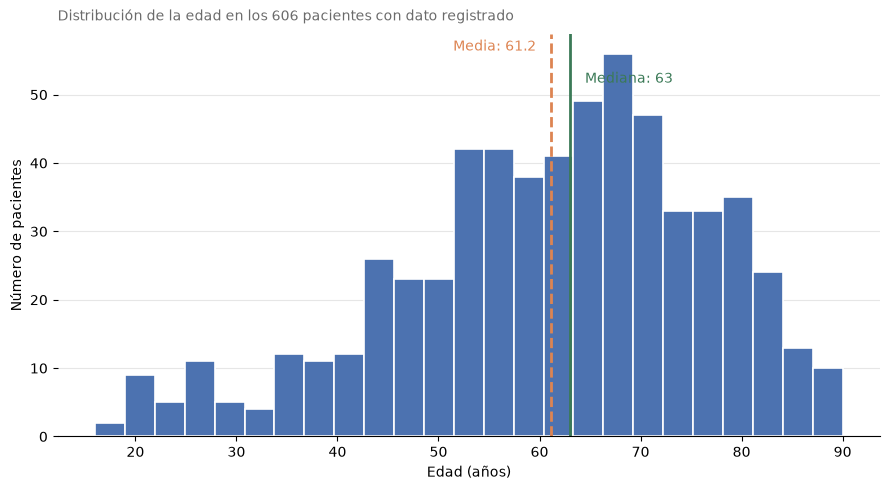

Asimetría (skew): -0.592
Media: 61.17  |  Mediana: 63.0  |  Diferencia: 1.83 años


In [10]:
edad = clinical_df['Age'].dropna()
media = edad.mean()
mediana = edad.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(edad, bins=25, color='#4C72B0', edgecolor='white', linewidth=1.2)

ax.axvline(media, color='#DD8452', linestyle='--', linewidth=2)
ax.axvline(mediana, color='#3B7A57', linestyle='-', linewidth=2)

ymax = ax.get_ylim()[1]
ax.text(media - 1.5, ymax * 0.96, f'Media: {media:.1f}', color='#DD8452',
        ha='right', fontsize=10)
ax.text(mediana + 1.5, ymax * 0.88, f'Mediana: {mediana:.0f}', color='#3B7A57',
        ha='left', fontsize=10)


ax.text(0, 1.035,
        f'Distribución de la edad en los {len(edad)} pacientes con dato registrado',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de pacientes')
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Asimetría (skew): {edad.skew():.3f}")
print(f"Media: {media:.2f}  |  Mediana: {mediana:.1f}  |  Diferencia: {abs(media-mediana):.2f} años")

El histograma confirma que la distribución de `Age` no es simétrica. El coeficiente de asimetría es de -0.592, un valor negativo que indica un sesgo hacia la izquierda de magnitud moderada, es decir, una cola que se extiende hacia las edades menores mientras el grueso de los datos se concentra en el extremo superior.

Visualmente esto se traduce en que la mayor densidad de pacientes se ubica entre los 50 y los 85 años, con el pico en el rango de 65 a 70, mientras que por debajo de los 45 años los casos son escasos y dispersos, extendiéndose hasta un mínimo de 16 años. Debido a lo anterior, la cola de pacientes jóvenes es la que arrastra la media hacia abajo.

La consecuencia directa se observa al comparar las dos medidas de tendencia central: la media es de 61.17 años y la mediana de 63.0, una diferencia de 1.83 años en la que la media queda por debajo de la mediana. En una distribución perfectamente simétrica ambos valores coincidirían, y su separación es precisamente la manifestación numérica del sesgo.

Por este motivo se seleccionó la **mediana** como estadístico de imputación. En distribuciones asimétricas la mediana constituye el estimador robusto de tendencia central, ya que depende de la posición central de los datos y no de la magnitud de los valores extremos, mientras que la media se desplaza en dirección a la cola y resulta menos representativa del paciente típico de la cohorte.

Cabe señalar adicionalmente que parte de esta asimetría es de origen artificial: la censura por anonimización aplicada por los autores del conjunto agrupa en el valor 90 a todos los pacientes mayores de 89 años, lo que trunca la cola derecha de la distribución y acentúa el sesgo negativo observado. Esta particularidad se aborda en detalle en la sección de valores atípicos.

In [11]:
escenarios = {
    'Sin tratar (n=606)': clinical_df['Age'].dropna(),
    'Eliminando el registro (n=606)': clinical_df['Age'].dropna(),
    'Imputando con la mediana (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].median()),
    'Imputando con la media (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].mean()),
}

resumen = pd.DataFrame({
    nombre: {
        'n': int(serie.count()),
        'Media': round(serie.mean(), 2),
        'Mediana': round(serie.median(), 2),
        'Desv. estándar': round(serie.std(), 2),
    }
    for nombre, serie in escenarios.items()
}).T

print("Efecto de cada alternativa de tratamiento sobre la distribución de Age:\n")
print(resumen.to_string())

Efecto de cada alternativa de tratamiento sobre la distribución de Age:

                                      n  Media  Mediana  Desv. estándar
Sin tratar (n=606)                606.0  61.17     63.0           15.65
Eliminando el registro (n=606)    606.0  61.17     63.0           15.65
Imputando con la mediana (n=607)  607.0  61.17     63.0           15.64
Imputando con la media (n=607)    607.0  61.17     63.0           15.64


Respecto al análisis del faltante frente a variables clave, el paciente afectado cuenta con información completa en el resto de las variables del conjunto, incluida la variable objetivo `Outcome`. Y la decisión de tratamiento se fundamenta en el efecto que cada alternativa produce sobre la distribución de la variable.

**Criterio de decisión y tratamiento aplicado para `Age`**

Se aplicó **imputación con la mediana (63 años)**, decisión que responde a dos criterios independientes.

El primero es si conservar o eliminar el registro. El análisis de sensibilidad muestra que la media, la mediana y la desviación estándar de `Age` permanecen prácticamente idénticas bajo cualquiera de las alternativas, por lo que la decisión resulta indiferente en términos de la distribución de la variable. Siendo así, el criterio pasa a ser preservar la mayor cantidad de información posible: eliminar el registro implicaría descartar también los datos completos de ese paciente en `Shockable Rhythm`, `OHCA`, `ROSC` y `Outcome`, sacrificando información valiosa a cambio de ningún beneficio.

El segundo criterio es con qué estadístico rellenar. Se optó por la mediana en lugar de la media porque la distribución de `Age` no es simétrica: presenta un sesgo hacia las edades menores, con valores atípicos de pacientes jóvenes por debajo de los 20 años y una acumulación artificial en el extremo superior producto de la censura en 90 años. En distribuciones asimétricas y con valores extremos, la mediana es el estimador robusto de tendencia central, mientras que la media se desplaza en dirección a los valores extremos y resulta menos representativa del paciente típico del conjunto.

In [12]:
mediana_age = clinical_df['Age'].median()
clinical_df['Age'] = clinical_df['Age'].fillna(mediana_age)

print(f"Imputación aplicada con la mediana: {mediana_age:.0f} años\n")
print("Estadística descriptiva final de Age:")
print(clinical_df['Age'].describe().round(2).to_string())

print(f"\nValores faltantes restantes en Age: {clinical_df['Age'].isnull().sum()}")
assert clinical_df['Age'].isnull().sum() == 0, "Aún quedan faltantes en Age"
print("Verificación superada: la variable Age no contiene valores faltantes.")

Imputación aplicada con la mediana: 63 años

Estadística descriptiva final de Age:
count    607.00
mean      61.17
std       15.64
min       16.00
25%       52.00
50%       63.00
75%       72.00
max       90.00

Valores faltantes restantes en Age: 0
Verificación superada: la variable Age no contiene valores faltantes.


**Variable `ROSC`**



`ROSC` (Return of Spontaneous Circulation) es una variable numérica continua que registra el tiempo transcurrido, en minutos, hasta el retorno de la circulación espontánea del paciente. Presenta 304 valores faltantes sobre 607 registros, equivalentes al 50.1% del conjunto, la proporción más alta de todo el dataset.

Este caso requiere un tratamiento distinto al de `Age`. Cuando la mitad de los valores de una variable están ausentes, la decisión no se limita a elegir un estadístico de relleno, sino que debe evaluarse previamente si la imputación es siquiera un procedimiento apropiado, dado que rellenar 304 registros implicaría que la mitad del contenido de la variable sería información generada artificialmente y no observada.

El análisis se estructura en cuatro pasos:
* Determinar el origen del faltante.
* Evaluar si su ausencia lleva información propia respecto al desenlace.
* Verificar si dicha asociación es genuina o está confundida por otra variable.
* Cuantificar el efecto que tendría la imputación sobre la distribución.




1. ¿Los pacientes sin dato presentan un desenlace distinto al de los demás?
2. Si es así, ¿esa diferencia se debe realmente a la ausencia del dato o a algún otro factor?
3. ¿Qué ocurre al controlar ese factor?
4. ¿Es viable imputar los valores faltantes?

In [13]:
clinical_df['ROSC'] = pd.to_numeric(clinical_df['ROSC'], errors='coerce')

n_total = len(clinical_df)
n_falt = clinical_df['ROSC'].isnull().sum()

print(f"Pacientes totales: {n_total}")
print(f"Pacientes sin dato de ROSC: {n_falt} ({n_falt/n_total*100:.1f}%)")
print(f"Pacientes con dato de ROSC: {n_total - n_falt}\n")

print("Estadística descriptiva de los casos con dato:")
print(clinical_df['ROSC'].describe().round(2).to_string())
print(f"\nAsimetría: {clinical_df['ROSC'].skew():.2f}   Curtosis: {clinical_df['ROSC'].kurt():.2f}")

Pacientes totales: 607
Pacientes sin dato de ROSC: 304 (50.1%)
Pacientes con dato de ROSC: 303

Estadística descriptiva de los casos con dato:
count    303.00
mean      23.27
std       18.79
min        1.00
25%       10.00
50%       19.00
75%       30.00
max      111.00

Asimetría: 1.85   Curtosis: 4.21




Solo 303 de los 607 pacientes cuentan con el dato. Entre ellos, el tiempo hasta la recuperación de la circulación tiene una mediana de 19 minutos y una media de 23.27, con valores que van de 1 a 111 minutos.

La asimetría de 1.85 y la curtosis de 4.21 indican una distribución con la mayoría de los casos en tiempos cortos y una cola larga de reanimaciones prolongadas. Por eso la media supera a la mediana en más de cuatro minutos: los casos extremos la arrastran hacia arriba.

Primera pregunta: ¿los pacientes sin dato presentan un desenlace distinto?

Antes de decidir cómo tratar los registros ausentes se debe verificar si corresponden a pacientes comparables al resto o si constituyen un grupo con características propias. La forma de comprobarlo es comparar el desenlace neurológico de ambos grupos.

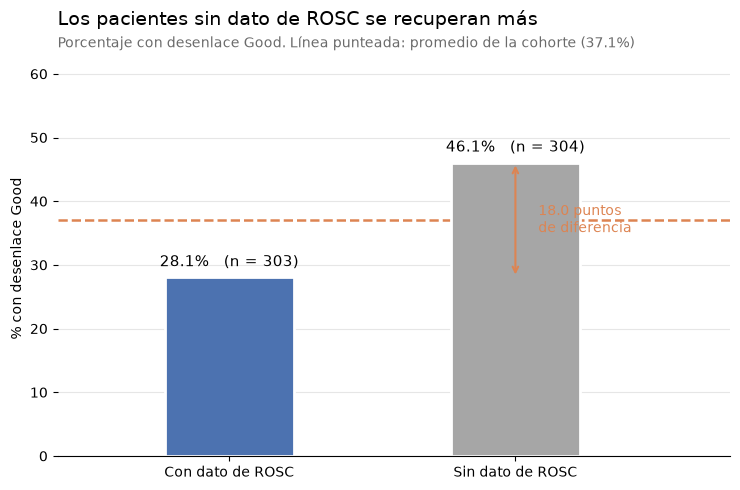

In [14]:
grupo = clinical_df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
tabla = pd.crosstab(grupo, clinical_df['Outcome']).reindex(['Con dato', 'Sin dato'])
pct_good = tabla['Good'] / tabla.sum(axis=1) * 100
conteos = tabla.sum(axis=1)
baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
barras = ax.bar(['Con dato de ROSC', 'Sin dato de ROSC'], pct_good.values, width=0.45,
                color=['#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%   (n = {int(n)})', ha='center', va='bottom', fontsize=10.5)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)
ax.annotate('', xy=(1, pct_good['Sin dato']), xytext=(1, pct_good['Con dato']),
            arrowprops=dict(arrowstyle='<->', color='#DD8452', lw=1.5))
ax.text(1.08, (pct_good['Sin dato'] + pct_good['Con dato'])/2,
        f"{pct_good['Sin dato'] - pct_good['Con dato']:.1f} puntos\nde diferencia",
        fontsize=10, color='#DD8452', va='center')

ax.set_title('Los pacientes sin dato de ROSC se recuperan más',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje con desenlace Good. Línea punteada: promedio de la cohorte ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, 62)
ax.set_xlim(-0.6, 1.75)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

Respuesta: sí, pero el resultado no tiene sentido clínico

Los pacientes sin dato de `ROSC` presentan un 46.1% de desenlaces favorables, frente a un 28.1% entre quienes sí lo tienen. Una diferencia de 18 puntos porcentuales.

Interpretado de forma literal, este resultado afirmaría que no tener el dato registrado mejora el pronóstico del paciente, lo cual es imposible: la omisión de un campo en un formulario no puede influir en la recuperación neurológica de nadie.

Cuando una comparación arroja un resultado sin sentido, la explicación habitual es que los dos grupos comparados difieren en algo más además de la característica que se está evaluando.

Segunda pregunta: ¿de dónde provienen los registros sin dato?

Si los pacientes sin dato no están repartidos de forma homogénea entre los hospitales, entonces la comparación anterior podría estar midiendo diferencias entre instituciones en lugar del efecto del dato ausente.

Disponibilidad de ROSC y desenlace por hospital:
              n  % sin dato ROSC  % Good
Hospital                                
A         261.0            100.0    46.7
B         120.0              0.0    28.3
D          83.0             26.5    32.5
E          74.0              2.7    20.3
F          69.0             27.5    39.1


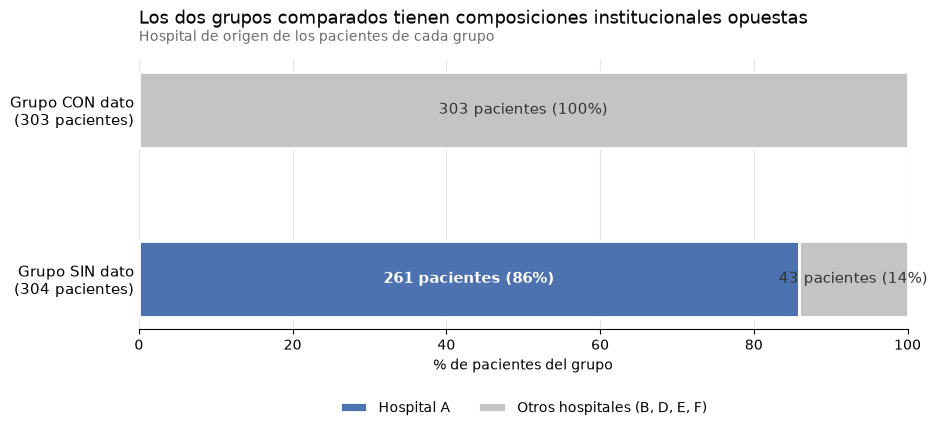

In [15]:
print("Disponibilidad de ROSC y desenlace por hospital:")
resumen_hosp = clinical_df.groupby('Hospital').apply(
    lambda g: pd.Series({
        'n': len(g),
        '% sin dato ROSC': g['ROSC'].isnull().mean() * 100,
        '% Good': (g['Outcome'] == 'Good').mean() * 100,
    }), include_groups=False
).round(1)
print(resumen_hosp.to_string())

# Composición de cada grupo según su hospital de origen
es_A = clinical_df['Hospital'] == 'A'
n_con = (grupo == 'Con dato').sum()
n_sin = (grupo == 'Sin dato').sum()
a_con = ((grupo == 'Con dato') & es_A).sum()
a_sin = ((grupo == 'Sin dato') & es_A).sum()

pct_a = [a_con/n_con*100, a_sin/n_sin*100]
pct_otros = [(n_con-a_con)/n_con*100, (n_sin-a_sin)/n_sin*100]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = [0, 1]
ax.barh(y, pct_a, 0.45, label='Hospital A', color='#4C72B0', edgecolor='white', linewidth=2)
ax.barh(y, pct_otros, 0.45, left=pct_a, label='Otros hospitales (B, D, E, F)',
        color='#C4C4C4', edgecolor='white', linewidth=2)

datos = [(pct_a[0], pct_otros[0], a_con, n_con-a_con, 0),
         (pct_a[1], pct_otros[1], a_sin, n_sin-a_sin, 1)]
for pa, po, na, no, i in datos:
    if pa > 5:
        ax.text(pa/2, i, f'{na} pacientes ({pa:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='white', weight='bold')
    if po > 5:
        ax.text(pa + po/2, i, f'{no} pacientes ({po:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='#333333')

ax.set_yticks(y)
ax.set_yticklabels([f'Grupo CON dato\n({n_con} pacientes)', f'Grupo SIN dato\n({n_sin} pacientes)'],
                   fontsize=10.5)
ax.set_xlim(0, 100)
ax.set_xlabel('% de pacientes del grupo')
ax.invert_yaxis()
ax.set_title('Los dos grupos comparados tienen composiciones institucionales opuestas',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.07, 'Hospital de origen de los pacientes de cada grupo',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: los faltantes provienen casi en su totalidad de un solo hospital

| Hospital | n | % sin dato de ROSC | % desenlace Good |
|---|---|---|---|
| A | 261 | 100.0% | 46.7% |
| B | 120 | 0.0% | 28.3% |
| D | 83 | 26.5% | 32.5% |
| E | 74 | 2.7% | 20.3% |
| F | 69 | 27.5% | 39.1% |

El Hospital A no registra esta variable en ninguno de sus 261 pacientes, mientras que el Hospital B la registra en los 120 suyos. No se trata de omisiones aisladas sino de una diferencia de protocolo entre instituciones.

La consecuencia se aprecia en el gráfico de composición: el grupo con dato no contiene ni un solo paciente del Hospital A, mientras que el grupo sin dato está formado en un 86% por pacientes de esa institución. Los dos grupos que se compararon en la primera pregunta no eran por lo tanto comparables entre sí.

Y aquí aparece el elemento decisivo: el Hospital A es además el que presenta el mejor desenlace de todo el conjunto, con 46.7% de recuperaciones favorables frente a un rango de 20.3% a 39.1% en los demás centros.

Esto significa que la comparación inicial no medía el efecto de la ausencia del dato, sino en gran medida el de pertenecer al Hospital A. La condición "no tener dato de ROSC" estaba funcionando como un sustituto de la condición "ser paciente del Hospital A".

¿Tercera pregunta: ¿qué ocurre si se elimina ese factor?

Si la diferencia la produjera realmente el dato ausente, excluir un hospital del análisis no debería alterarla de forma apreciable. Si en cambio la producía el Hospital A, la diferencia debería reducirse al retirarlo.

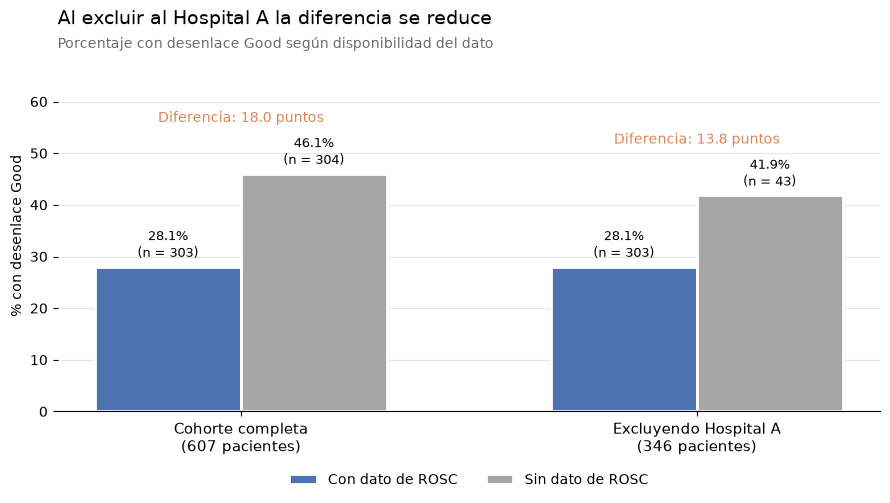

In [16]:
def desenlace_por_disponibilidad(df):
    g = df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
    t = pd.crosstab(g, df['Outcome']).reindex(['Con dato', 'Sin dato'])
    return (t['Good'] / t.sum(axis=1) * 100), t.sum(axis=1)

pct_full, n_full = desenlace_por_disponibilidad(clinical_df)
sin_A = clinical_df[clinical_df['Hospital'] != 'A']
pct_sinA, n_sinA = desenlace_por_disponibilidad(sin_A)

x = np.arange(2)
w = 0.32
con = [pct_full['Con dato'], pct_sinA['Con dato']]
sin = [pct_full['Sin dato'], pct_sinA['Sin dato']]
n_con_l = [n_full['Con dato'], n_sinA['Con dato']]
n_sin_l = [n_full['Sin dato'], n_sinA['Sin dato']]

fig, ax = plt.subplots(figsize=(9, 5.2))
b1 = ax.bar(x - w/2, con, w, label='Con dato de ROSC', color='#4C72B0',
            edgecolor='white', linewidth=2)
b2 = ax.bar(x + w/2, sin, w, label='Sin dato de ROSC', color='#A6A6A6',
            edgecolor='white', linewidth=2)

for barras, enes in ((b1, n_con_l), (b2, n_sin_l)):
    for barra, n in zip(barras, enes):
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.0,
                f'{alto:.1f}%\n(n = {int(n)})', ha='center', va='bottom', fontsize=9.5)

for i, (c, s) in enumerate(zip(con, sin)):
    ax.text(i, max(c, s) + 10, f'Diferencia: {s-c:.1f} puntos',
            ha='center', fontsize=10, color='#DD8452')

ax.set_title('Al excluir al Hospital A la diferencia se reduce',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035, 'Porcentaje con desenlace Good según disponibilidad del dato',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_xticks(x)
ax.set_xticklabels(['Cohorte completa\n(607 pacientes)',
                    f'Excluyendo Hospital A\n({len(sin_A)} pacientes)'], fontsize=10.5)
ax.set_ylim(0, 68)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: parte de la diferencia se explica por el hospital, y el resto no puede evaluarse

Al excluir al Hospital A, la diferencia baja de 18 a 13.8 puntos porcentuales, quedando repartida en dos porciones.

Los 4.2 puntos que desaparecen corresponden al Hospital A. La atribución es inequívoca porque el grupo con dato no cambió entre ambos escenarios, ya que ninguno de esos 303 pacientes pertenecía a esa institución. Queda confirmado que parte del efecto aparente venía del hospital y no del dato ausente.

Los 13.8 puntos restantes no pueden evaluarse, porque ahora se calculan sobre 43 pacientes en lugar de 304. Con ese tamaño, cada paciente vale 2.3 puntos del resultado, de modo que el cambio de desenlace de tres casos bastaría para reducir la diferencia a la mitad. No se afirma que sea inexistente, sino que la muestra es demasiado pequeña para saberlo.

Cuarta pregunta: ¿es viable imputar los valores faltantes?

Descartado que el faltante tenga significado propio, queda por resolver si conviene rellenarlo. Para decidirlo se compara la distribución real de la variable con la que resultaría después de imputar.

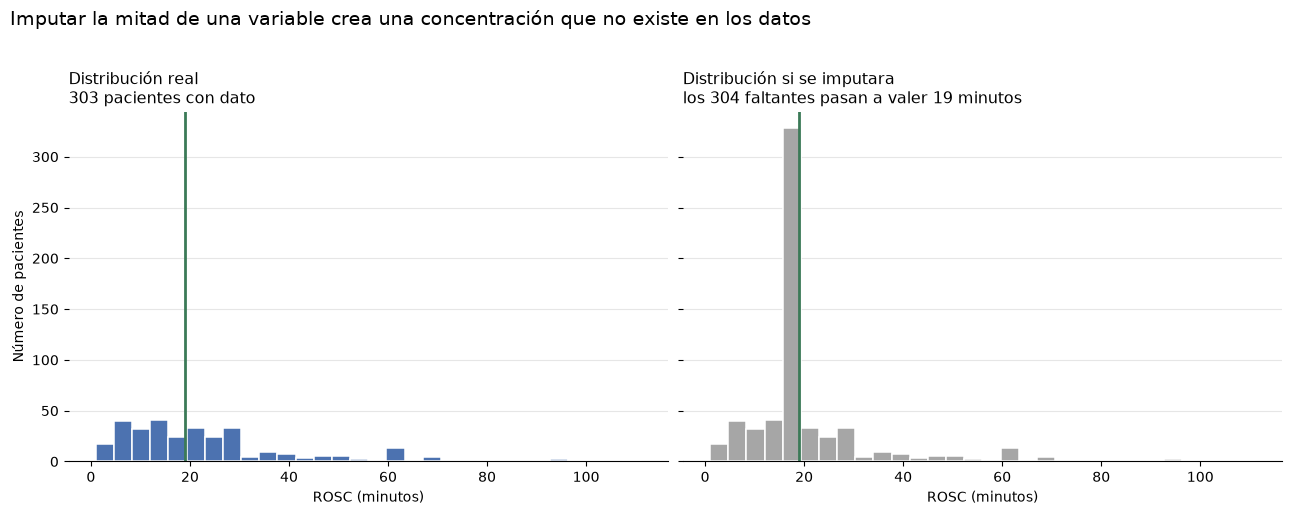

Desviación estándar real: 18.79
Desviación estándar tras imputar: 13.44
Pérdida de variabilidad: 28.5%


In [17]:
rosc = clinical_df['ROSC'].dropna()
mediana_rosc = rosc.median()
imputado = clinical_df['ROSC'].fillna(mediana_rosc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax1.hist(rosc, bins=30, color='#4C72B0', edgecolor='white', linewidth=1.1)
ax1.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax1.set_title(f'Distribución real\n{len(rosc)} pacientes con dato', fontsize=11.5, loc='left')
ax1.set_xlabel('ROSC (minutos)')
ax1.set_ylabel('Número de pacientes')

ax2.hist(imputado, bins=30, color='#A6A6A6', edgecolor='white', linewidth=1.1)
ax2.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax2.set_title(f'Distribución si se imputara\nlos 304 faltantes pasan a valer {mediana_rosc:.0f} minutos',
              fontsize=11.5, loc='left')
ax2.set_xlabel('ROSC (minutos)')

for ax in (ax1, ax2):
    ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ('top', 'right', 'left'):
        ax.spines[lado].set_visible(False)

fig.suptitle('Imputar la mitad de una variable crea una concentración que no existe en los datos',
             fontsize=13.5, x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.show()

print(f"Desviación estándar real: {rosc.std():.2f}")
print(f"Desviación estándar tras imputar: {imputado.std():.2f}")
print(f"Pérdida de variabilidad: {(1 - imputado.std()/rosc.std())*100:.1f}%")

Respuesta: no es viable imputar

El contraste entre ambos histogramas muestra el efecto de rellenar los 304 registros con la mediana: se genera una acumulación de más de 320 pacientes en el valor de 19 minutos, una concentración inexistente en los datos observados. La desviación estándar cae de 18.79 a 13.44, lo que representa una pérdida del 28.5% de la variabilidad de la variable.

En una variable donde los valores ausentes constituyen la mitad del conjunto, la imputación implica que la mitad de su contenido pasaría a ser información generada artificialmente.

**Criterio de decisión y tratamiento aplicado**

Ninguna de las tres alternativas convencionales resulta apropiada. Imputar distorsionaría la distribución en la magnitud descrita. Eliminar los registros implicaría descartar 304 pacientes, más de la mitad de la cohorte y la totalidad del Hospital A. Y conservar una variable indicadora del faltante carece de justificación, dado que se demostró que la ausencia del dato no aporta información clínica sino institucional.

El tratamiento adoptado consta por lo tanto de dos componentes.

El primero es conservar la variable numérica `ROSC` con sus valores nulos, sin modificación. En pandas, `NaN` constituye la representación nativa del dato no disponible en variables numéricas y se excluye de forma automática del cálculo de estadísticos y de la generación de gráficos. Los análisis sobre el tiempo exacto de reanimación se realizan en consecuencia sobre los 303 pacientes con información disponible.

El segundo responde a una limitación del primero: mantener los valores nulos deja al 50.1% de la cohorte inutilizable en cualquier análisis que requiera la variable. Por ello se construye adicionalmente `ROSC_cat`, una versión agrupada en tres rangos definidos por los cuartiles observados, que incorpora la ausencia del dato como una categoría explícita.



In [18]:
# 1. La variable numérica conserva sus valores nulos, sin imputar.
print(f"Valores nulos conservados en ROSC: {clinical_df['ROSC'].isnull().sum()} "
      f"({clinical_df['ROSC'].isnull().mean()*100:.1f}%)")
print(f"Pacientes con dato disponible: {clinical_df['ROSC'].notna().sum()}")

# 2. Versión agrupada que mantiene utilizable a toda la cohorte.
#    Cortes definidos por los cuartiles observados (Q1 = 10, Q3 = 30).
clinical_df['ROSC_cat'] = pd.cut(
    clinical_df['ROSC'],
    bins=[0, 10, 30, float('inf')],
    labels=['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)']
)
clinical_df['ROSC_cat'] = clinical_df['ROSC_cat'].cat.add_categories('Sin dato').fillna('Sin dato')

orden_cat = ['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)', 'Sin dato']

print("\nDistribución de ROSC_cat:")
for cat, n in clinical_df['ROSC_cat'].value_counts().reindex(orden_cat).items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

# 3. Validación: los rangos deben conservar la relación con el desenlace
print("\n% con desenlace Good por categoría:")
val = clinical_df.groupby('ROSC_cat', observed=True).apply(
    lambda g: (g['Outcome'] == 'Good').mean() * 100, include_groups=False
).reindex(orden_cat).round(1)
print(val.to_string())

assert clinical_df['ROSC_cat'].isnull().sum() == 0, "ROSC_cat contiene nulos"
print(f"\nVerificación superada: ROSC_cat cubre los {len(clinical_df)} pacientes sin valores nulos.")

Valores nulos conservados en ROSC: 304 (50.1%)
Pacientes con dato disponible: 303

Distribución de ROSC_cat:
  Rápido (1-10 min): 86 (14.2%)
  Intermedio (11-30 min): 158 (26.0%)
  Prolongado (>30 min): 59 (9.7%)
  Sin dato: 304 (50.1%)

% con desenlace Good por categoría:
ROSC_cat
Rápido (1-10 min)         38.4
Intermedio (11-30 min)    26.6
Prolongado (>30 min)      16.9
Sin dato                  46.1

Verificación superada: ROSC_cat cubre los 607 pacientes sin valores nulos.



Debe dejarse explícito que, al no registrar el Hospital A esta variable en ninguno de sus pacientes, todo análisis sobre `ROSC` en este proyecto, incluidos los realizados en la Fase 2, se sustenta en una subcohorte que excluye por completo a la institución que aporta el 43% de los pacientes y que además presenta el mejor desenlace del conjunto. Los hallazgos sobre la relación entre el tiempo hasta el retorno de la circulación espontánea y el desenlace neurológico deben interpretarse por lo tanto como válidos para los hospitales B, D, E y F, sin que pueda asumirse su generalización a la totalidad de la cohorte.

Esta limitación afecta específicamente a los análisis que emplean la variable numérica `ROSC`, calculados sobre los 303 pacientes con dato disponible. Los análisis que utilicen `ROSC_cat` sí abarcan la totalidad de los 607 registros, aunque en ellos el Hospital A queda representado íntegramente dentro de la categoría "Sin dato", de modo que cualquier comparación entre esa categoría y las demás estará reflejando también una diferencia institucional y no únicamente el tiempo de reanimación.

Finalmente, esta situación constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos, dado que evidencia una ausencia de estandarización en los protocolos de registro entre las instituciones del consorcio, y debería tenerse en cuenta en cualquier estudio posterior que pretenda emplear esta variable como predictor del desenlace neurológico.

**Variable TTM**

`TTM` (Targeted Temperature Management) registra la temperatura objetivo del manejo de temperatura dirigido aplicado al paciente, expresada en grados centígrados. Presenta 98 valores faltantes sobre 607 registros, equivalentes al 16.1% del conjunto.

Esta variable constituye el único caso del conjunto de datos en el que la ausencia del valor no representa un problema de calidad, sino información clínica en sí misma. Según la documentación oficial de I-CARE, el valor nulo en `TTM` no corresponde a un dato que no se logró capturar, sino que está codificado de forma explícita para indicar que al paciente no se le aplicó manejo de temperatura dirigido. Se trata por lo tanto de un faltante estructural: el dato no existe porque el procedimiento no se realizó, no porque se haya omitido su registro.

Esta distinción cambia por completo el criterio de tratamiento. En las variables anteriores la pregunta era cómo manejar la ausencia de una información que sí existía; aquí la pregunta es cómo representar una categoría clínica que el formato numérico de la variable no permite expresar.

In [19]:


n_total = len(clinical_df)
n_falt = clinical_df['TTM'].isnull().sum()

print(f"Tipo de dato: {clinical_df['TTM'].dtype}")
print(f"Valores faltantes en TTM: {n_falt} ({n_falt/n_total*100:.1f}%)\n")

print("Valores observados en la variable:")
print(clinical_df['TTM'].value_counts(dropna=False).sort_index().to_string())

print("\nEstadística descriptiva de los casos con dato:")
print(clinical_df['TTM'].describe().round(2).to_string())

print("\nDistribución por hospital de los pacientes SIN TTM:")
falt_hosp = clinical_df.loc[clinical_df['TTM'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Sin TTM': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Sin TTM'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Tipo de dato: float64
Valores faltantes en TTM: 98 (16.1%)

Valores observados en la variable:
TTM
33.0    448
36.0     61
NaN      98

Estadística descriptiva de los casos con dato:
count    509.00
mean      33.36
std        0.98
min       33.00
25%       33.00
50%       33.00
75%       33.00
max       36.00

Distribución por hospital de los pacientes SIN TTM:
          Sin TTM  Total pacientes  % del hospital
Hospital                                          
A               2              261             0.8
B               9              120             7.5
D              20               83            24.1
E               3               74             4.1
F              64               69            92.8




La variable presenta únicamente dos valores distintos en los 509 pacientes con dato: 33 °C en 448 casos y 36 °C en 61. Esto confirma de forma definitiva que `TTM` no constituye una variable continua sino una categórica almacenada en formato numérico, correspondiente a dos protocolos clínicos de temperatura objetivo. La media de 33.36 que arroja la estadística descriptiva carece de sentido clínico, dado que ningún paciente registra esa temperatura.

Respecto al origen de los 98 casos sin TTM, la distribución institucional es la siguiente:

| Hospital | Sin TTM | Total pacientes | % del hospital |
|---|---|---|---|
| A | 2 | 261 | 0.8% |
| B | 9 | 120 | 7.5% |
| D | 20 | 83 | 24.1% |
| E | 3 | 74 | 4.1% |
| F | 64 | 69 | 92.8% |

El Hospital F concentra 64 de los 98 casos, es decir el 65% del total, y no aplica el procedimiento en el 92.8% de sus pacientes. A diferencia de lo observado en `ROSC`, donde la ausencia del dato respondía a una omisión de registro, aquí el patrón refleja una decisión de protocolo clínico: esa institución no incorpora el manejo de temperatura dirigido en su práctica habitual. 

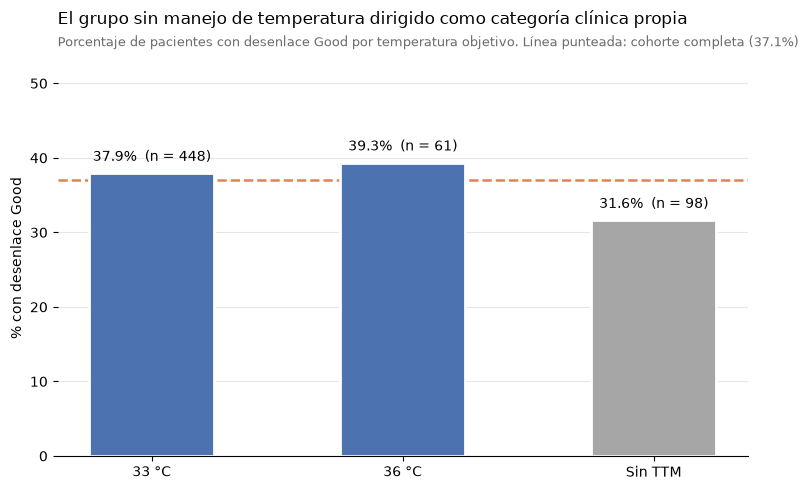

TTM_grupo
33 °C      37.9
36 °C      39.3
Sin TTM    31.6


In [20]:
clinical_df['TTM_grupo'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']
tabla = pd.crosstab(clinical_df['TTM_grupo'], clinical_df['Outcome']).reindex(orden)
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(orden, pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'],
                edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('El grupo sin manejo de temperatura dirigido como categoría clínica propia',
             fontsize=12.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good por temperatura objetivo. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

Comportamiento del grupo sin TTM frente al desenlace

| Categoría | % con desenlace Good | n |
|---|---|---|
| 33 °C | 37.9% | 448 |
| 36 °C | 39.3% | 61 |
| Sin TTM | 31.6% | 98 |
| **Cohorte completa** | **37.1%** | **607** |

Dos observaciones se desprenden de esta comparación.

La primera es que ambas temperaturas objetivo producen resultados prácticamente equivalentes, con una diferencia de apenas 1.4 puntos porcentuales entre 33 y 36 grados. Este hallazgo es consistente con la evidencia clínica disponible, que no ha logrado establecer una ventaja de la hipotermia profunda frente al control de temperatura menos agresivo.



**Criterio de decisión y tratamiento aplicado en el  `TTM`**

Se decidió recodificar `TTM` como variable categórica de tres niveles**: `33 °C`, `36 °C` y `Sin TTM`.

La decisión se fundamenta en que ninguna de las alternativas habituales resulta admisible en este caso. Imputar un valor sería el error más grave, porque asignar 33 o 36 grados a esos 98 pacientes equivaldría a afirmar que recibieron un tratamiento que en realidad nunca se les administró. No se trataría de una aproximación estadística imprecisa sino de una afirmación clínicamente falsa. Eliminar los registros tampoco procede, dado que no existe ningún dato perdido que justifique descartarlos: la información sobre esos pacientes está completa, y lo que el valor nulo indica es precisamente que el procedimiento no se aplicó. Y conservar el valor como `NaN`, que fue la solución adoptada para `ROSC`, resultaría aquí inadecuado, porque `NaN` significa "dato desconocido" mientras que en esta variable el contenido real es "condición clínica conocida y documentada".

La recodificación como categoría explícita es por lo tanto la única representación fiel al significado del dato. El análisis previo la respalda empíricamente, al mostrar que el grupo sin TTM presenta un comportamiento diferenciado frente al desenlace que no se explica por el hospital de procedencia.

La conversión a tipo categórico no implica además ninguna pérdida de información, dado que la variable solo contiene dos valores distintos y su formato numérico original nunca aportó capacidad analítica real. Por el contrario, la recodificación corrige una inconsistencia entre el tipo de dato y la naturaleza de la variable que venía arrastrándose desde la adquisición, y permite que los 607 pacientes queden disponibles para cualquier análisis posterior, frente a los 509 que resultaban utilizables en su formato original.

In [21]:
# Recodificación de TTM como variable categórica de tres niveles.
# El valor nulo no representa un dato desconocido sino una condición clínica
# documentada: el paciente no recibió manejo de temperatura dirigido.
clinical_df['TTM_cat'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']

print("Distribución final de TTM_cat:")
dist = clinical_df['TTM_cat'].value_counts().reindex(orden)
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nPacientes utilizables: {clinical_df['TTM_cat'].notna().sum()} de {len(clinical_df)}")
print(f"Valores nulos en TTM_cat: {clinical_df['TTM_cat'].isnull().sum()}")

assert clinical_df['TTM_cat'].isnull().sum() == 0, "TTM_cat contiene nulos"
print("\nVerificación superada: TTM_cat cubre la totalidad de la cohorte sin valores nulos.")

Distribución final de TTM_cat:
  33 °C: 448 (73.8%)
  36 °C: 61 (10.0%)
  Sin TTM: 98 (16.1%)

Pacientes utilizables: 607 de 607
Valores nulos en TTM_cat: 0

Verificación superada: TTM_cat cubre la totalidad de la cohorte sin valores nulos.


**Tratamiento de datos faltantes para las variables categoricas**

In [22]:
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]

print("Valores faltantes en las variables categóricas:\n")

total = 0
for col in categorical_cols:
    nan_texto = (clinical_df[col].astype(str).str.strip().str.lower() == 'nan').sum()
    pct = nan_texto / len(clinical_df) * 100
    print(f"{col}: {nan_texto} faltantes ({pct:.1f}%)")
    total += nan_texto

print(f"\nTotal de faltantes en variables categóricas: {total}")

Valores faltantes en las variables categóricas:

Sex: 3 faltantes (0.5%)
Hospital: 0 faltantes (0.0%)
OHCA: 41 faltantes (6.8%)
Shockable Rhythm: 32 faltantes (5.3%)
Outcome: 0 faltantes (0.0%)
CPC: 0 faltantes (0.0%)

Total de faltantes en variables categóricas: 76


**Valores faltantes en las variables categóricas**

El conteo confirma que solo tres de las seis variables categóricas presentan valores faltantes, sumando 76 registros en total:

| Variable | Faltantes | Porcentaje |
|---|---|---|
| `Sex` | 3 | 0.5% |
| `OHCA` | 41 | 6.8% |
| `Shockable Rhythm` | 32 | 5.3% |
| `Hospital` | 0 | 0.0% |
| `Outcome` | 0 | 0.0% |
| `CPC` | 0 | 0.0% |

Tres hallazgos relevantes se desprenden de este resultado.

Primero, la variable objetivo (`Outcome`) y su variable asociada (`CPC`) están completas para los 607 pacientes. Esto es especialmente importante, porque un faltante en la variable objetivo obligaría a descartar esos registros por completo al no poder usarse ni para caracterización ni para modelado posterior. Al estar completas, se conserva la totalidad de la cohorte para el análisis del desenlace.

Segundo, `Hospital` también está completa, lo que permite usarla con confianza como variable de estratificación o control en análisis posteriores, sin riesgo de perder pacientes al agrupar por institución.

Tercero, los faltantes se concentran en variables clínicas del evento (`OHCA` y `Shockable Rhythm`), con porcentajes moderados pero no despreciables (6.8% y 5.3%). Estas dos describen las circunstancias del paro cardíaco, información que suele registrarse en el contexto prehospitalario y que puede no estar disponible cuando el paro no fue presenciado o cuando el paciente fue remitido desde otra institución. Su ausencia no es un simple vacío administrativo, sino que puede reflejar situaciones clínicas particulares, por lo que requieren una decisión de tratamiento cuidadosa y no una imputación automática.

**Variable `Sex`**

`Sex` es una variable con dos categorías válidas (`Male` y `Female`) que registra el género del paciente. En la Fase 2 se identificó que presenta valores faltantes, los cuales estaban ocultos como el texto literal `"nan"` y no como valores nulos reales de pandas.

A continuación se cuantifica la magnitud del faltante y se evalúa su impacto sobre la representatividad de la variable antes de decidir el tratamiento.

In [23]:
# Normalizar el "nan" de texto a un valor nulo real reconocible por pandas
clinical_df['Sex'] = clinical_df['Sex'].replace('nan', pd.NA)

n_total = len(clinical_df)
n_falt = clinical_df['Sex'].isnull().sum()

print(f"Total de pacientes: {n_total}")
print(f"Valores faltantes en Sex: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Distribución de las categorías conocidas:")
print(clinical_df['Sex'].value_counts(dropna=False).to_string())

Total de pacientes: 607
Valores faltantes en Sex: 3 (0.49%)

Distribución de las categorías conocidas:
Sex
Male      417
Female    187
NaN         3


In [24]:
faltantes = clinical_df[clinical_df['Sex'].isnull()]

print("Perfil de los pacientes sin dato de Sex:")
print(faltantes[['Patient', 'Hospital', 'Age', 'OHCA',
                 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']].to_string(index=False))

print("\nHospital de procedencia de los faltantes:")
print(faltantes['Hospital'].value_counts().to_string())

Perfil de los pacientes sin dato de Sex:
Patient Hospital  Age  OHCA Shockable Rhythm  ROSC Outcome CPC
   0405        B 26.0 False            False   2.0    Poor   5
   0592        F 63.0  True            False   NaN    Good   1
   0788        D 67.0   nan            False   NaN    Poor   5

Hospital de procedencia de los faltantes:
Hospital
B    1
F    1
D    1


**Identificación y análisis del faltante**

La variable `Sex` presenta 3 valores faltantes sobre 607 pacientes, equivalentes al 0.49% del total. Las categorías conocidas se distribuyen en 417 hombres y 187 mujeres.

Respecto a la distribución de los faltantes frente a variables clave, los 3 pacientes afectados cuentan con información completa en el resto de variables clínicas relevantes, incluida la variable objetivo `Outcome`. Cabe precisar que, con únicamente 3 casos, cualquier comparación estadística de este subgrupo frente al resto de la cohorte carece de poder para ser concluyente, por lo que la decisión de tratamiento no se fundamenta en el perfil de estos pacientes, sino en un análisis de sensibilidad sobre la variable completa.

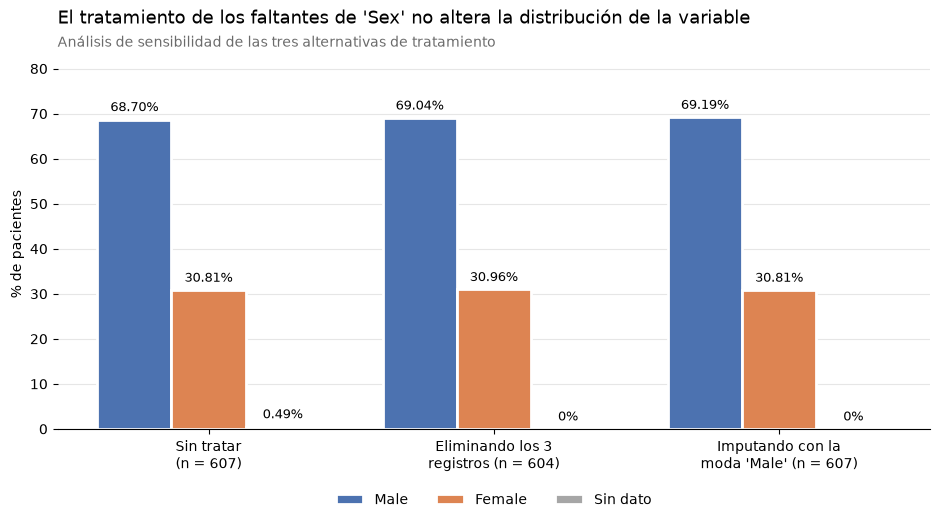

In [25]:
n_male = (clinical_df['Sex'] == 'Male').sum()
n_female = (clinical_df['Sex'] == 'Female').sum()
n_falt = clinical_df['Sex'].isnull().sum()
n_conocidos = n_male + n_female

escenarios = [
    f"Sin tratar\n(n = {n_total})",
    f"Eliminando los {n_falt}\nregistros (n = {n_conocidos})",
    f"Imputando con la\nmoda 'Male' (n = {n_total})",
]
male     = [n_male/n_total*100, n_male/n_conocidos*100, (n_male + n_falt)/n_total*100]
female   = [n_female/n_total*100, n_female/n_conocidos*100, n_female/n_total*100]
sin_dato = [n_falt/n_total*100, 0.0, 0.0]

x = np.arange(len(escenarios))
w = 0.26

fig, ax = plt.subplots(figsize=(9.5, 5.4))
b1 = ax.bar(x - w, male, w, label='Male', color='#4C72B0', edgecolor='white', linewidth=2)
b2 = ax.bar(x, female, w, label='Female', color='#DD8452', edgecolor='white', linewidth=2)
b3 = ax.bar(x + w, sin_dato, w, label='Sin dato', color='#A6A6A6', edgecolor='white', linewidth=2)

for barras in (b1, b2, b3):
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.2,
                f'{alto:.2f}%' if alto > 0 else '0%',
                ha='center', va='bottom', fontsize=9)

ax.set_title("El tratamiento de los faltantes de 'Sex' no altera la distribución de la variable",
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035, 'Análisis de sensibilidad de las tres alternativas de tratamiento',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% de pacientes')
ax.set_xticks(x)
ax.set_xticklabels(escenarios)
ax.set_ylim(0, 82)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3)

plt.tight_layout()
plt.show()

**Criterio de decisión y tratamiento aplicado**

Para decidir entre eliminar los registros o imputarlos, se realizó un análisis de sensibilidad comparando la distribución resultante de `Sex` bajo los tres escenarios posibles.

El resultado muestra que la proporción de hombres se mantiene entre 68.70% y 69.19%, y la de mujeres entre 30.81% y 30.96%, independientemente del tratamiento aplicado. La diferencia máxima entre eliminar los registros e imputarlos con la moda es de 0.15 puntos porcentuales, una variación sin ninguna relevancia práctica para el análisis.

Dado que ambas alternativas producen esencialmente el mismo resultado sobre la variable, el criterio de decisión pasa a ser cuál de las dos preserva mayor cantidad de información. Por esta razón se optó por **imputar los 3 valores con la moda (`Male`)** en lugar de eliminar los registros, con base en tres consideraciones:

1. Los 3 pacientes afectados cuentan con datos completos en variables clínicamente más determinantes para el desenlace, como `Shockable Rhythm`, `ROSC` y `Outcome`. Eliminarlos implicaría descartar esa información a cambio de un beneficio nulo.
2. El conjunto de datos es relativamente pequeño (607 pacientes) y la clase minoritaria de la variable objetivo cuenta con solo 225 casos `Good`, por lo que la pérdida de registros debe evitarse siempre que sea posible.
3. En la Fase 2 se estableció que `Sex` presenta una asociación muy débil con el desenlace neurológico. Esto se evidenció en el gráfico de **barras de proporción de `Outcome` según `Sex`**, donde la diferencia en la proporción de casos `Good` entre hombres y mujeres fue de apenas 6 puntos porcentuales (38.6% frente a 32.8%), y se confirmó numéricamente en la **matriz de correlación extendida**, donde `Sex_num` presentó una correlación cercana a cero con `Outcome_num`, muy por debajo de la de otras variables como `Shockable Rhythm` (-0.37). Dado que el sexo no es un factor determinante del desenlace en este conjunto de datos, una eventual imputación incorrecta en 3 pacientes no introduce sesgo apreciable en los análisis de asociación posteriores.

In [26]:
moda_sex = clinical_df['Sex'].mode()[0]
clinical_df['Sex'] = clinical_df['Sex'].fillna(moda_sex)

print(f"Imputación aplicada con la moda: '{moda_sex}'\n")
print("Distribución final de Sex:")
print(clinical_df['Sex'].value_counts().to_string())
print(f"\nValores faltantes restantes en Sex: {clinical_df['Sex'].isnull().sum()}")

assert clinical_df['Sex'].isnull().sum() == 0, "Aún quedan faltantes en Sex"
print("Verificación superada: la variable Sex no contiene valores faltantes.")


Imputación aplicada con la moda: 'Male'

Distribución final de Sex:
Sex
Male      420
Female    187

Valores faltantes restantes en Sex: 0
Verificación superada: la variable Sex no contiene valores faltantes.


**Variable `OHCA`**

`OHCA` (Out-of-Hospital Cardiac Arrest) es una variable categórica binaria que indica si el paro cardíaco ocurrió fuera del hospital (`True`) o dentro de este (`False`). Es la variable categórica con mayor proporción de valores faltantes del conjunto de datos.

A diferencia de `Sex`, donde el faltante era marginal, aquí el grupo sin dato es lo suficientemente grande como para evaluar si su ausencia responde a un patrón sistemático. Por ello el criterio de decisión no será un análisis de sensibilidad, sino determinar si el faltante constituye en sí mismo información relevante frente a la variable objetivo.

In [27]:
clinical_df['OHCA'] = clinical_df['OHCA'].replace('nan', pd.NA)

n_falt = clinical_df['OHCA'].isnull().sum()
print(f"Valores faltantes en OHCA: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['OHCA'].value_counts(dropna=False).to_string())

print("\nDistribución por hospital de los pacientes SIN dato de OHCA:")
falt_hosp = clinical_df.loc[clinical_df['OHCA'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Valores faltantes en OHCA: 41 (6.8%)

Distribución de las categorías:
OHCA
True     442
False    124
NaN       41

Distribución por hospital de los pacientes SIN dato de OHCA:
          Faltantes  Total pacientes  % del hospital
Hospital                                            
A                26              261            10.0
B                 0              120             0.0
D                11               83            13.3
E                 3               74             4.1
F                 1               69             1.4


**Análisis de la distribución de los faltantes**

Al examinar el origen institucional de los 41 registros sin dato, se observa que los faltantes no se distribuyen de manera uniforme entre los hospitales del consorcio:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 26 | 261 | 10.0% |
| B | 0 | 120 | 0.0% |
| D | 11 | 83 | 13.3% |
| E | 3 | 74 | 4.1% |
| F | 1 | 69 | 1.4% |

La proporción de faltantes varía entre 0.0% y 13.3% según la institución, y los hospitales A y D concentran 37 de los 41 casos (90%). El contraste más notorio es el del Hospital B, que no presenta ningún valor faltante en 120 pacientes, frente al Hospital D, con 13.3% de sus registros incompletos.

Este patrón indica que la ausencia del dato no responde a una característica clínica de los pacientes, sino a diferencias en las prácticas de registro y documentación entre instituciones. Es decir, se trata de un faltante asociado a la variable `Hospital` y no aleatorio en sentido estricto.

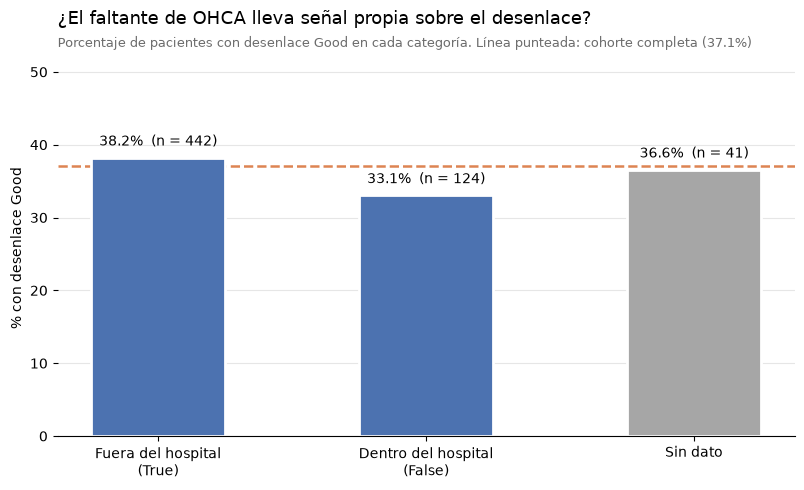

OHCA
True        38.2
False       33.1
Sin dato    36.6


In [28]:
# Los nulos reales se convierten a texto ANTES de agrupar. En versiones recientes de
# pandas, .astype(str) no transforma pd.NA en '<NA>' sino que lo conserva como nulo,
# y pd.crosstab descarta esas filas, haciendo desaparecer la categoría "Sin dato".
grupos = (clinical_df['OHCA']
          .astype(object)
          .fillna('Sin dato')
          .astype(str)
          .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                    'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Fuera del hospital\n(True)', 'Dentro del hospital\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('¿El faltante de OHCA lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good en cada categoría. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())


**Evaluación de si el faltante lleva señal propia**

Para determinar si la ausencia del dato constituye información relevante, se comparó la proporción de pacientes con desenlace `Good` en cada categoría de `OHCA`, incluyendo el grupo sin dato.

| Categoría | % con desenlace Good | n |
|---|---|---|
| Fuera del hospital (`True`) | 38.2% | 442 |
| Dentro del hospital (`False`) | 33.1% | 124 |
| Sin dato | 36.6% | 41 |
| **Cohorte completa** | **37.1%** | **607** |

El grupo sin dato presenta un 36.6% de desenlaces favorables, prácticamente idéntico al 37.1% de la cohorte completa y ubicado entre las dos categorías conocidas. Esto indica que los pacientes sin registro de `OHCA` no constituyen un subgrupo con un pronóstico diferenciado, sino que se comportan como el promedio del conjunto de datos. El hallazgo sugiere que la ausencia del dato se debe a diferencias en las prácticas de documentación institucional y no a características clínicas de los pacientes.

**Criterio de decisión y tratamiento aplicado**

Con ambas evidencias se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros.

La decisión se fundamenta en una asimetría de costos entre las alternativas. Conservar la categoría no tiene costo analítico, dado que el grupo sin dato se comporta como el promedio de la cohorte y por lo tanto no distorsiona las comparaciones de desenlace entre categorías. Imputar con la moda, en cambio, sí tiene un costo concreto: desplazaría la distribución de la variable de 72.8% a 79.6% de casos `True`, y atribuiría a 41 pacientes una característica clínica desconocida, cuando la única causa documentada de la ausencia es la práctica de registro de sus hospitales de origen. Eliminar los registros tampoco es viable, porque los faltantes se concentran en los hospitales A y D, lo que sub-representaría sistemáticamente a esas instituciones en todos los análisis posteriores.

Se evaluó adicionalmente una imputación por moda dentro de cada hospital, más refinada que la moda global, pero se descartó porque el 90% de los faltantes proviene de A y D, donde la moda también es `True`, con lo cual el resultado sería equivalente al de la imputación global sin resolver el problema de fondo.

Finalmente, conservar una tercera categoría no representa ninguna limitación para las fases posteriores, ya que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [29]:
clinical_df['OHCA'] = clinical_df['OHCA'].astype(object).fillna('Desconocido')

print("Distribución final de OHCA:")
dist = clinical_df['OHCA'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes en OHCA: {clinical_df['OHCA'].isnull().sum()}")
assert clinical_df['OHCA'].isnull().sum() == 0, "Aún quedan faltantes en OHCA"
print("Verificación superada: la variable OHCA no contiene valores faltantes.")

Distribución final de OHCA:
  True: 442 (72.8%)
  False: 124 (20.4%)
  Desconocido: 41 (6.8%)

Valores faltantes restantes en OHCA: 0
Verificación superada: la variable OHCA no contiene valores faltantes.


**Variable `Shockable Rhythm`**

`Shockable Rhythm` es una variable categórica binaria que indica si el ritmo cardíaco inicial del paciente era desfibrilable (`True`), por ejemplo fibrilación ventricular, o no desfibrilable (`False`). Presenta 32 valores faltantes, equivalentes al 5.3% del conjunto.

Esta variable requiere el criterio de tratamiento más cuidadoso, por dos razones establecidas en la Fase 2. Primero, es la variable con la asociación más fuerte con el desenlace neurológico de todo el conjunto de datos: presentó la correlación de mayor magnitud con `Outcome` (-0.37) y una diferencia de 38 puntos porcentuales en la proporción de casos `Good` entre sus dos categorías (55% con ritmo desfibrilable frente a 17% sin él). Segundo, sus dos categorías están prácticamente equilibradas (297 casos `True` frente a 278 `False`), a diferencia de `OHCA`, donde existía una mayoría clara.

Cualquier valor asignado de forma incorrecta en esta variable tiene, por lo tanto, un impacto mucho mayor sobre los análisis posteriores que en las variables anteriores.

In [30]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].replace('nan', pd.NA)

n_falt = clinical_df['Shockable Rhythm'].isnull().sum()
print(f"Valores faltantes en Shockable Rhythm: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['Shockable Rhythm'].value_counts(dropna=False).to_string())

conocidos = clinical_df['Shockable Rhythm'].dropna()
print("\nDistribución entre los casos conocidos (%):")
print((conocidos.value_counts(normalize=True) * 100).round(1).to_string())

print("\nDistribución por hospital de los pacientes SIN dato:")
falt_hosp = clinical_df.loc[clinical_df['Shockable Rhythm'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Valores faltantes en Shockable Rhythm: 32 (5.3%)

Distribución de las categorías:
Shockable Rhythm
True     297
False    278
NaN       32

Distribución entre los casos conocidos (%):
Shockable Rhythm
True     51.7
False    48.3

Distribución por hospital de los pacientes SIN dato:
          Faltantes  Total pacientes  % del hospital
Hospital                                            
A                32              261            12.3
B                 0              120             0.0
D                 0               83             0.0
E                 0               74             0.0
F                 0               69             0.0


**Análisis de la distribución de los faltantes**

El examen del origen institucional de los 32 registros sin dato arroja un resultado inequívoco:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 32 | 261 | 12.3% |
| B | 0 | 120 | 0.0% |
| D | 0 | 83 | 0.0% |
| E | 0 | 74 | 0.0% |
| F | 0 | 69 | 0.0% |

La totalidad de los valores faltantes proviene del Hospital A, mientras que los cuatro hospitales restantes no presentan ni un solo registro incompleto en 346 pacientes. Se trata por lo tanto de una carencia de documentación exclusiva de una institución, sin relación con las características clínicas de los pacientes.

Este hallazgo es más categórico que el observado en `OHCA`, donde los faltantes se repartían en distinta proporción entre cuatro hospitales. Aquí la ausencia del dato depende por completo del centro de origen, lo que descarta interpretarla como una señal clínica.

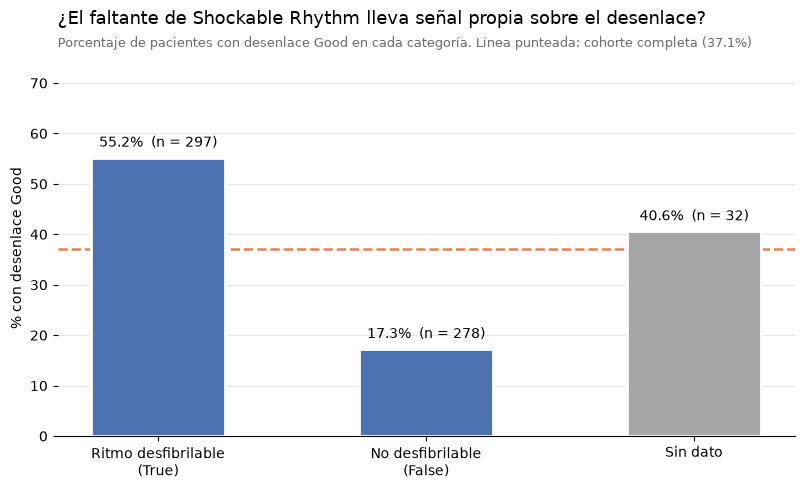

Shockable Rhythm
True        55.2
False       17.3
Sin dato    40.6


In [31]:
grupos = (clinical_df['Shockable Rhythm']
          .astype(object)
          .fillna('Sin dato')
          .astype(str)
          .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                    'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Ritmo desfibrilable\n(True)', 'No desfibrilable\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.5,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('¿El faltante de Shockable Rhythm lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good en cada categoría. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

In [32]:
# Costo cuantitativo de imputar con la moda.
# La celda es autocontenida: recalcula los grupos en vez de depender de celdas previas.
grupos_sr = (clinical_df['Shockable Rhythm']
             .astype(object)
             .fillna('Sin dato')
             .astype(str)
             .replace({'nan': 'Sin dato', '<NA>': 'Sin dato',
                       'None': 'Sin dato', 'Desconocido': 'Sin dato'}))

tabla_sr = pd.crosstab(grupos_sr, clinical_df['Outcome']).reindex(['True', 'False', 'Sin dato'])
pct_sr = (tabla_sr['Good'] / tabla_sr.sum(axis=1) * 100)

conocidos = grupos_sr[grupos_sr.isin(['True', 'False'])]
n_falt_sr = int((grupos_sr == 'Sin dato').sum())

moda = conocidos.mode()[0]
pct_moda = (conocidos == moda).mean() * 100
error_esperado = round(n_falt_sr * (1 - pct_moda / 100))

print(f"Moda de la variable: '{moda}', presente en {pct_moda:.1f}% de los casos conocidos")
print(f"Al imputar los {n_falt_sr} faltantes con la moda se esperaría clasificar")
print(f"incorrectamente alrededor de {error_esperado} pacientes ({100 - pct_moda:.1f}% de ellos).\n")

# Composición implícita del grupo sin dato, estimada a partir de su tasa de desenlace favorable
prop_true_estimada = (pct_sr['Sin dato'] - pct_sr['False']) / (pct_sr['True'] - pct_sr['False'])
print("Composición estimada del grupo sin dato a partir de su tasa de desenlace favorable:")
print(f"  aproximadamente {prop_true_estimada*100:.0f}% True  ({round(n_falt_sr*prop_true_estimada)} pacientes)")
print(f"  aproximadamente {(1-prop_true_estimada)*100:.0f}% False ({round(n_falt_sr*(1-prop_true_estimada))} pacientes)")


Moda de la variable: 'True', presente en 51.7% de los casos conocidos
Al imputar los 32 faltantes con la moda se esperaría clasificar
incorrectamente alrededor de 15 pacientes (48.3% de ellos).

Composición estimada del grupo sin dato a partir de su tasa de desenlace favorable:
  aproximadamente 62% True  (20 pacientes)
  aproximadamente 38% False (12 pacientes)


**Evaluación de si el faltante lleva señal propia**

| Categoría | % con desenlace Good | n |
|---|---|---|
| Ritmo desfibrilable (`True`) | 55.2% | 297 |
| No desfibrilable (`False`) | 17.3% | 278 |
| Sin dato | 40.6% | 32 |
| **Cohorte completa** | **37.1%** | **607** |

La diferencia entre las dos categorías conocidas es de 37.9 puntos porcentuales, la mayor observada entre todas las variables del conjunto, lo que confirma a `Shockable Rhythm` como el factor pronóstico más determinante disponible.

El grupo sin dato presenta un 40.6% de desenlaces favorables, un valor que no se aproxima a ninguna de las dos categorías conocidas y que se ubica cerca del promedio general de la cohorte. Este comportamiento intermedio es característico de un grupo mixto y no de uno que pertenezca mayoritariamente a una sola categoría. Asumiendo que su tasa de desenlace favorable corresponde a una combinación ponderada de ambas categorías, la proporción implícita de casos `True` en ese grupo sería cercana al 61%, es decir, alrededor de 20 pacientes `True` y 12 `False`.

**Criterio de decisión y tratamiento aplicado**

Se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros. Esta es la variable donde dicha decisión cuenta con el fundamento más sólido de las tres, por cuatro razones.

Primero, la moda no constituye una mayoría significativa. Entre los casos conocidos la distribución es de 51.7% `True` frente a 48.3% `False`, prácticamente equilibrada. La imputación por moda es un procedimiento defendible cuando existe una categoría claramente dominante, pero con una mayoría del 51.7% equivale a asignar valores casi de forma aleatoria.

Segundo, el costo del error es el más alto del conjunto de datos. Al estimarse que cerca de 12 de los 32 pacientes pertenecen realmente a la categoría `False`, imputarlos todos como `True` los desplazaría desde un grupo con 17.3% de desenlaces favorables hacia uno con 55.2%, introduciendo ruido precisamente en la variable con mayor capacidad discriminante sobre el desenlace neurológico.

Tercero, el perfil intermedio del grupo sin dato indica que se trata de una mezcla de ambas categorías, por lo que ningún valor único sería representativo del conjunto de pacientes afectados.

Cuarto, la totalidad de los faltantes proviene del Hospital A. Eliminar esos registros sub-representaría a la institución que aporta el 43% de la cohorte, mientras que imputarlos ocultaría un hallazgo relevante sobre la calidad del registro en ese centro. Conservar la categoría explícita mantiene visible esa limitación de los datos en lugar de disimularla.

Al igual que en `OHCA`, la tercera categoría no representa ninguna limitación técnica para las fases posteriores, dado que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [33]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].astype(object).fillna('Desconocido')

print("Distribución final de Shockable Rhythm:")
dist = clinical_df['Shockable Rhythm'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes: {clinical_df['Shockable Rhythm'].isnull().sum()}")
assert clinical_df['Shockable Rhythm'].isnull().sum() == 0, "Aún quedan faltantes"
print("Verificación superada: la variable Shockable Rhythm no contiene valores faltantes.")

Distribución final de Shockable Rhythm:
  True: 297 (48.9%)
  False: 278 (45.8%)
  Desconocido: 32 (5.3%)

Valores faltantes restantes: 0
Verificación superada: la variable Shockable Rhythm no contiene valores faltantes.


**Hallazgo transversal sobre la calidad del registro**

Al comparar el origen de los faltantes de las tres variables categóricas se identifica un patrón que trasciende cada caso individual. Los 32 faltantes de `Shockable Rhythm` provienen en su totalidad del Hospital A, y 26 de los 41 faltantes de `OHCA` provienen de esa misma institución. En conjunto, el Hospital A concentra 58 de los 76 valores faltantes del conjunto de variables categóricas, es decir el 76% del total.

Esto indica que no se trata de incidencias aisladas e independientes en cada variable, sino de una deficiencia sistemática en las prácticas de documentación de las circunstancias del paro cardíaco en ese centro. Dado que el Hospital A aporta el 43% de la cohorte, esta limitación debe tenerse presente al interpretar cualquier análisis que involucre estas dos variables, y constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos.

**Verificación final de la sección**

Una vez aplicados los tratamientos a las seis variables con valores ausentes, se verifica el estado final del conjunto de datos. El resultado esperado es que ninguna variable conserve valores nulos, con la única excepción de `ROSC`, cuyos 304 registros se mantienen deliberadamente sin imputar según el criterio justificado en su apartado correspondiente.


In [34]:
# Se elimina la columna auxiliar creada únicamente para construir el gráfico de TTM
clinical_df = clinical_df.drop(columns=['TTM_grupo'], errors='ignore')

print("Estado final de los valores faltantes tras la sección 1.1:\n")
print(clinical_df.isnull().sum().to_string())

# ROSC y TTM conservan sus nulos de forma deliberada, cada una por su propio criterio:
#   ROSC: imputar la mitad de la variable distorsionaría su distribución. Su versión
#         utilizable para toda la cohorte es ROSC_cat.
#   TTM:  el nulo representa una condición clínica documentada ("no se aplicó el
#         procedimiento"). Su versión recodificada es TTM_cat.
deliberados = ['ROSC', 'TTM']
falt_tratadas = clinical_df.drop(columns=deliberados).isnull().sum().sum()

print(f"\nValores faltantes en las variables tratadas: {falt_tratadas}")
print("\nNulos conservados de forma deliberada:")
print(f"  ROSC: {clinical_df['ROSC'].isnull().sum():>3}  (versión completa disponible en ROSC_cat)")
print(f"  TTM:  {clinical_df['TTM'].isnull().sum():>3}  (versión completa disponible en TTM_cat)")

assert falt_tratadas == 0, "Quedan valores faltantes sin tratar"
assert clinical_df['ROSC_cat'].isnull().sum() == 0, "ROSC_cat contiene nulos"
assert clinical_df['TTM_cat'].isnull().sum() == 0, "TTM_cat contiene nulos"

print("\nVerificación superada: todas las variables quedaron tratadas. Los nulos restantes")
print("en ROSC y TTM son intencionales y cuentan con su equivalente completo en")
print("ROSC_cat y TTM_cat, que cubren los 607 pacientes.")


Estado final de los valores faltantes tras la sección 1.1:

Patient               0
Hospital              0
Age                   0
Sex                   0
ROSC                304
OHCA                  0
Shockable Rhythm      0
TTM                  98
Outcome               0
CPC                   0
ROSC_cat              0
TTM_cat               0

Valores faltantes en las variables tratadas: 0

Nulos conservados de forma deliberada:
  ROSC: 304  (versión completa disponible en ROSC_cat)
  TTM:   98  (versión completa disponible en TTM_cat)

Verificación superada: todas las variables quedaron tratadas. Los nulos restantes
en ROSC y TTM son intencionales y cuentan con su equivalente completo en
ROSC_cat y TTM_cat, que cubren los 607 pacientes.


**Respuesta a las preguntas de la sección**

**¿Cómo afectan estos valores a la integridad y representatividad de la información?**

El conjunto presenta 479 valores ausentes distribuidos en 6 de sus 10 variables, equivalentes al 7.9% de las celdas totales. Su efecto sobre la integridad es desigual según la variable: mientras en `Age` (1 caso) y `Sex` (3 casos) resulta despreciable, en `ROSC` alcanza el 50.1% del conjunto y limita seriamente cualquier análisis que dependa de esa variable.

El efecto sobre la representatividad es el aspecto más delicado, y no proviene de la cantidad de datos ausentes sino de su distribución. Los faltantes no se reparten de forma homogénea entre las instituciones: el Hospital A concentra 321 de los 479 valores ausentes, es decir el 67% del total, y en el caso de `ROSC` no registra la variable en ninguno de sus 261 pacientes. Dado que ese hospital aporta el 43% de la cohorte y presenta el mejor desenlace del conjunto, cualquier decisión de eliminar registros incompletos habría sub-representado de forma severa a la institución más grande y con mejores resultados, distorsionando la composición del estudio. Este riesgo fue determinante en las decisiones adoptadas: en ninguna variable se eliminaron registros, y los 607 pacientes se conservaron íntegros.

**¿Cómo se identificaron los valores faltantes en el conjunto de datos?**

La identificación requirió dos pasos, porque el método directo resultaba engañoso. Al ejecutar `clinical_df.isnull().sum()` sobre los datos recién adquiridos, el resultado indicaba cero valores faltantes en las diez columnas. Ese resultado era falso: los datos provienen de archivos de texto plano donde los campos sin valor quedaron registrados como el texto literal `"nan"`, que pandas interpreta como una cadena de caracteres válida y no como un dato ausente.

Detectada la discrepancia entre ese conteo y las categorías `"nan"` visibles en los gráficos de la Fase 2, se procedió a verificar que ese fuera efectivamente el único código de faltante empleado. Para las variables numéricas se comprobó, mediante `pd.to_numeric(errors="coerce")`, que `'nan'` era el único valor no convertible a número. Para las categóricas se revisaron todos sus valores únicos, descartando la presencia de otras variantes como `"NA"`, `"-"`, `"?"` o cadenas vacías.

Confirmado el diagnóstico, se normalizaron los valores a nulos reales de pandas: mediante `pd.to_numeric(errors="coerce")` en `Age`, `ROSC` y `TTM`, y mediante `.replace('nan', pd.NA)` en `Sex`, `OHCA` y `Shockable Rhythm`. Solo entonces el conteo reflejó la magnitud real del problema.

**¿Cuáles fueron los criterios para decidir si rellenar o eliminar los valores faltantes? ¿Qué método de relleno se utilizó y por qué?**

No se eliminó ningún registro en ninguna de las seis variables, por el riesgo de sub-representación institucional ya descrito y porque el conjunto es pequeño, con solo 225 casos en la clase minoritaria de la variable objetivo. El criterio de tratamiento se definió caso por caso, en función de la magnitud del faltante, de su origen y de las consecuencias de cada alternativa:

| Variable | Faltantes | Tratamiento | Criterio |
|---|---|---|---|
| `Age` | 1 (0.2%) | Imputación con la mediana (63 años) | El análisis de sensibilidad mostró que ninguna alternativa altera la distribución. Se eligió la mediana por la asimetría de la variable |
| `Sex` | 3 (0.5%) | Imputación con la moda (`Male`) | La distribución varía menos de 0.15 puntos porcentuales bajo cualquier tratamiento, por lo que se optó por preservar los registros |
| `OHCA` | 41 (6.8%) | Categoría explícita `"Desconocido"` | Imputar desplazaría la distribución de 72.8% a 79.6% y atribuiría una condición clínica desconocida a 41 pacientes |
| `Shockable Rhythm` | 32 (5.3%) | Categoría explícita `"Desconocido"` | La moda representa apenas el 51.7% de los casos, por lo que imputar equivaldría a asignar valores casi al azar en la variable más asociada al desenlace |
| `TTM` | 98 (16.1%) | Recodificación a categoría `"Sin TTM"` | El valor nulo no indica un dato desconocido sino una condición clínica documentada: el procedimiento no se aplicó |
| `ROSC` | 304 (50.1%) | Conservación del nulo más versión agrupada `ROSC_cat` | Imputar la mitad de la variable concentraría 320 pacientes en un único valor y reduciría su variabilidad en 28.5% |

El criterio transversal que orientó estas decisiones fue evitar la generación de información inexistente. La imputación solo se aplicó donde resultaba inocua, es decir, en las dos variables cuyo faltante era marginal y donde se verificó empíricamente que la elección no alteraba la distribución. En el resto se optó por hacer explícita la ausencia mediante una categoría propia, preservando así la totalidad de los registros sin fabricar valores.

**¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave?**

Sí, en dos dimensiones para cada variable afectada.

La primera fue el origen institucional, que reveló que los faltantes responden a prácticas de registro y no a características de los pacientes. Los casos más evidentes son `ROSC`, ausente en el 100% de los pacientes del Hospital A y en el 0% de los del Hospital B, y `Shockable Rhythm`, cuyos 32 faltantes provienen en su totalidad del Hospital A.

La segunda fue la relación con la variable objetivo `Outcome`, orientada a determinar si la ausencia del dato constituía información pronóstica. Este análisis produjo el hallazgo metodológicamente más relevante de la sección. En `ROSC`, los pacientes sin dato mostraban un 46.1% de desenlaces favorables frente a un 28.1% de quienes sí lo tenían, una diferencia de 18 puntos que, interpretada literalmente, sugeriría que la ausencia del registro mejora el pronóstico. Al identificarse que el 86% de esos faltantes provenía del Hospital A, que es además el hospital con mejor desenlace, se repitió la comparación excluyéndolo, y la diferencia se redujo a 13.8 puntos calculados sobre apenas 43 pacientes. Se concluyó que la asociación aparente correspondía al hospital de origen y no al dato ausente.

La implicación para la interpretación de los resultados es directa y debe tenerse presente en las fases posteriores: dado que el Hospital A no aporta ningún valor de `ROSC`, todo análisis que involucre esa variable se sustenta en una subcohorte de 303 pacientes que excluye por completo a la institución más grande del estudio, por lo que sus conclusiones no pueden generalizarse a la cohorte completa.

### **1.2. Valores duplicados**
----
Ante la presencia de valores duplicados, es esencial reflexionar sobre su impacto en los resultados.

* ¿Cómo se identificaron y manejaron los valores duplicados en el conjunto de datos?
* ¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?
* ¿Pueden estos duplicados sesgar el análisis, y en qué medida?
* ¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?
* ¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?

La identificación y eliminación de duplicados busca asegurar que cada registro aporte información única y valiosa.

--------------------------------------------------------------------------

En este conjunto de datos cada fila corresponde a un paciente distinto, identificado por la variable `Patient`. Un duplicado significaría por lo tanto que un mismo paciente quedó registrado dos veces, lo que inflaría artificialmente el peso de ese caso en cualquier estadístico o modelo posterior.

La verificación se realiza en tres niveles, porque no todos los chequeos de duplicados detectan lo mismo:

1. **Filas completamente idénticas**, incluyendo el identificador. Es el chequeo estándar, pero también el más débil en este contexto: al ser `Patient` un identificador único, dos filas no pueden coincidir en todas sus columnas salvo que el propio identificador esté repetido.
2. **Identificadores repetidos.** Detecta si un mismo código de paciente aparece más de una vez, que es el error de captura más común en registros clínicos.
3. **Perfiles clínicos idénticos, ignorando el identificador.** Detecta el caso en que un mismo paciente haya sido registrado dos veces bajo códigos distintos, algo que los dos chequeos anteriores no alcanzarían a ver.

In [35]:
n_total = len(clinical_df)
cols_clinicas = [c for c in clinical_df.columns if c != 'Patient']

dup_filas = clinical_df.duplicated().sum()
dup_ids = clinical_df['Patient'].duplicated().sum()
dup_perfil = clinical_df.duplicated(subset=cols_clinicas).sum()

print(f"Total de registros: {n_total}\n")
print(f"1. Filas completamente idénticas:            {dup_filas}")
print(f"2. Identificadores de paciente repetidos:    {dup_ids}")
print(f"3. Perfiles clínicos idénticos (sin el ID):  {dup_perfil}")
print(f"\nRegistros únicos según el identificador: {clinical_df['Patient'].nunique()} de {n_total}")

Total de registros: 607

1. Filas completamente idénticas:            0
2. Identificadores de paciente repetidos:    0
3. Perfiles clínicos idénticos (sin el ID):  49

Registros únicos según el identificador: 607 de 607


**Resultado de la verificación**

Los dos primeros niveles no detectan ninguna anomalía: no existen filas completamente idénticas ni identificadores de paciente repetidos, y los 607 códigos son únicos.

El tercer nivel, en cambio, detecta 49 registros cuyo perfil clínico coincide exactamente con el de otro paciente. Antes de concluir que se trata de duplicados y proceder a eliminarlos, es necesario determinar si corresponden a un error de registro o a una coincidencia fortuita, ya que con variables de pocas categorías dos pacientes distintos pueden compartir el mismo perfil sin que exista ningún error.

In [36]:
mascara = clinical_df.duplicated(subset=cols_clinicas, keep=False)
sospechosos = clinical_df[mascara]

print(f"Registros involucrados en perfiles repetidos: {len(sospechosos)}\n")

print("Hospital de origen de esos registros:")
print(sospechosos['Hospital'].value_counts().to_string())

print(f"\nDe esos {len(sospechosos)} registros, cuántos carecen del dato de ROSC: "
      f"{sospechosos['ROSC'].isnull().sum()}")

# Prueba decisiva: ¿hay perfiles repetidos entre los pacientes que SÍ tienen ROSC?
con_rosc = clinical_df[clinical_df['ROSC'].notna()]
dup_con_rosc = con_rosc.duplicated(subset=cols_clinicas).sum()
print(f"\nPerfiles repetidos entre los {len(con_rosc)} pacientes CON dato de ROSC: {dup_con_rosc}")

tam = clinical_df.groupby(cols_clinicas, dropna=False).size()
print(f"\nGrupos con perfil repetido: {(tam > 1).sum()}")
print(f"Tamaño del grupo más grande: {tam.max()} pacientes")
print("\nDistribución del tamaño de los grupos repetidos:")
print(tam[tam > 1].value_counts().sort_index().to_string())

Registros involucrados en perfiles repetidos: 84

Hospital de origen de esos registros:
Hospital
A    84

De esos 84 registros, cuántos carecen del dato de ROSC: 84

Perfiles repetidos entre los 303 pacientes CON dato de ROSC: 0

Grupos con perfil repetido: 35
Tamaño del grupo más grande: 5 pacientes

Distribución del tamaño de los grupos repetidos:
2    24
3     9
4     1
5     1


In [37]:
simulacion = clinical_df.drop_duplicates(subset=cols_clinicas)
eliminados = clinical_df[~clinical_df.index.isin(simulacion.index)]

print("Simulación: efecto de aplicar drop_duplicates() sin analizar el origen\n")
print(f"Pacientes antes:   {len(clinical_df)}")
print(f"Pacientes después: {len(simulacion)}")
print(f"Pacientes eliminados: {len(eliminados)} ({len(eliminados)/len(clinical_df)*100:.1f}% de la cohorte)\n")

print("Hospital de procedencia de los pacientes que se habrían eliminado:")
print(eliminados['Hospital'].value_counts().to_string())

n_a_antes = (clinical_df['Hospital'] == 'A').sum()
n_a_despues = (simulacion['Hospital'] == 'A').sum()
print(f"\nHospital A pasaría de {n_a_antes} a {n_a_despues} pacientes "
      f"(pérdida del {(n_a_antes-n_a_despues)/n_a_antes*100:.1f}% de esa institución)")
print(f"Su peso en la cohorte pasaría de {n_a_antes/len(clinical_df)*100:.1f}% "
      f"a {n_a_despues/len(simulacion)*100:.1f}%")

Simulación: efecto de aplicar drop_duplicates() sin analizar el origen

Pacientes antes:   607
Pacientes después: 558
Pacientes eliminados: 49 (8.1% de la cohorte)

Hospital de procedencia de los pacientes que se habrían eliminado:
Hospital
A    49

Hospital A pasaría de 261 a 212 pacientes (pérdida del 18.8% de esa institución)
Su peso en la cohorte pasaría de 43.0% a 38.0%



La investigación arroja un resultado inequívoco. Los 84 registros involucrados en perfiles repetidos provienen en su totalidad del Hospital A, y a los 84 les falta el dato de `ROSC`. Entre los 303 pacientes que sí cuentan con esa variable no existe ni un solo perfil repetido. Como se documentó en la sección anterior, el Hospital A no registra `ROSC` en ninguno de sus 261 pacientes, y esa es la única variable del conjunto con un rango amplio de valores distintos.

Se concluye que **no existen duplicados reales en el conjunto de datos**. Las 49 coincidencias corresponden a pacientes distintos que resultan indistinguibles entre sí únicamente porque carecen de la variable que los diferenciaría.

---

**¿Cómo se identificaron y manejaron los valores duplicados?**

La identificación se realizó en tres niveles de exigencia creciente: filas completamente idénticas (0 casos), identificadores de paciente repetidos (0 casos) y perfiles clínicos idénticos ignorando el identificador (49 casos). Ante el resultado del tercer nivel no se procedió a eliminar los registros, sino a investigar su origen mediante el análisis de su procedencia institucional y su relación con las variables faltantes. Concluida esa investigación, no se eliminó ningún registro.

**¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?**

Sí, dos. La primera es que el chequeo estándar `duplicated()` resulta engañoso en este conjunto, porque al incluir el identificador único `Patient` en la comparación nunca podría detectar dos registros del mismo paciente bajo códigos distintos. Por eso se repitió el análisis excluyendo esa columna. La segunda es que la variable `ROSC` resultó determinante para interpretar el resultado: su ausencia en la totalidad de los pacientes del Hospital A es la causa directa de las coincidencias observadas.

**¿Pueden estos duplicados sesgar el análisis, y en qué medida?**

Al no tratarse de duplicados reales, no introducen ningún sesgo: cada uno de los 607 registros corresponde a un paciente distinto y aporta información propia. El riesgo de sesgo en este caso no provenía de conservarlos sino de eliminarlos.

**¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?**

No. La eliminación se justifica cuando un mismo registro aparece repetido, lo que no ocurre aquí. Aplicar `drop_duplicates()` de forma automática habría descartado 49 pacientes reales, equivalentes al 8.1% de la cohorte, y habría reducido el Hospital A de 261 a 212 pacientes, una pérdida del 18.8% de esa institución. Se habría eliminado información clínica legítima por una coincidencia derivada de un vacío de registro.

**¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?**

Dado que no se eliminó ningún registro, la representación del conjunto se conserva íntegra: los 607 pacientes y la distribución por hospital permanecen sin alteración. La verificación se realizó de forma preventiva mediante una simulación del efecto que habría tenido la eliminación automática, cuyo resultado confirma que el procedimiento habría sub-representado de manera severa al hospital que aporta el mayor número de pacientes al estudio.

### **1.3. Valores atípicos**
---
Al abordar valores atípicos, es relevante cuestionarse sobre la naturaleza de estos puntos extremos.
* ¿Son errores de medición o representan información válida pero excepcional?
* ¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?
* ¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?
* ¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?

La elección entre eliminar o transformar estos valores debe basarse en su influencia en la distribución y la interpretación de los resultados, asegurando que el análisis refleje de manera precisa la realidad del conjunto de datos.

------------------------------------------------------------------------------------------

El análisis de valores atípicos aplica únicamente a las variables numéricas continuas del conjunto, que tras el tratamiento de la sección anterior se reducen a dos: `Age` y `ROSC`. La variable `TTM` quedó recodificada como categórica al confirmarse que solo contiene dos valores de protocolo clínico, y el resto de variables son categóricas o identificadores, donde el concepto de valor atípico no resulta aplicable.

La detección se realiza combinando dos enfoques: uno estadístico, mediante el criterio del rango intercuartílico, y uno visual, mediante diagramas de caja. La cuestión central no es únicamente identificar qué valores son extremos, sino determinar si corresponden a errores de medición o a información clínica válida pero excepcional, ya que de esa distinción depende por completo la decisión de tratamiento.

In [45]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['Age', 'ROSC']:
    s = clinical_df[col].dropna()
    q1, q3, iqr, inf, sup = limites_iqr(s)
    bajos = s[s < inf]
    altos = s[s > sup]

    print(f"--- {col}  (n = {len(s)}) ---")
    print(f"  Rango observado: {s.min():.0f} a {s.max():.0f}")
    print(f"  Q1 = {q1:.1f}   Q3 = {q3:.1f}   IQR = {iqr:.1f}")
    print(f"  Límites del criterio IQR: [{inf:.1f}, {sup:.1f}]")
    print(f"  Atípicos por debajo del límite inferior: {len(bajos)}")
    print(f"  Atípicos por encima del límite superior: {len(altos)}")
    print(f"  Total de atípicos: {len(bajos) + len(altos)} "
          f"({(len(bajos)+len(altos))/len(s)*100:.1f}% de los casos con dato)")
    if len(bajos):
        print(f"  Valores por debajo: {[int(v) for v in sorted(bajos.unique())]}")
    if len(altos):
        print(f"  Valores por encima: {[int(v) for v in sorted(altos.unique())]}")
    print()

--- Age  (n = 607) ---
  Rango observado: 16 a 90
  Q1 = 52.0   Q3 = 72.0   IQR = 20.0
  Límites del criterio IQR: [22.0, 102.0]
  Atípicos por debajo del límite inferior: 11
  Atípicos por encima del límite superior: 0
  Total de atípicos: 11 (1.8% de los casos con dato)
  Valores por debajo: [16, 17, 19, 20, 21]

--- ROSC  (n = 303) ---
  Rango observado: 1 a 111
  Q1 = 10.0   Q3 = 30.0   IQR = 20.0
  Límites del criterio IQR: [-20.0, 60.0]
  Atípicos por debajo del límite inferior: 0
  Atípicos por encima del límite superior: 13
  Total de atípicos: 13 (4.3% de los casos con dato)
  Valores por encima: [62, 63, 67, 70, 80, 90, 95, 96, 98, 100, 111]



C:\Users\aleja\AppData\Local\Temp\ipykernel_21396\3237733215.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(s, vert=False, widths=0.5, patch_artist=True,
C:\Users\aleja\AppData\Local\Temp\ipykernel_21396\3237733215.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(s, vert=False, widths=0.5, patch_artist=True,


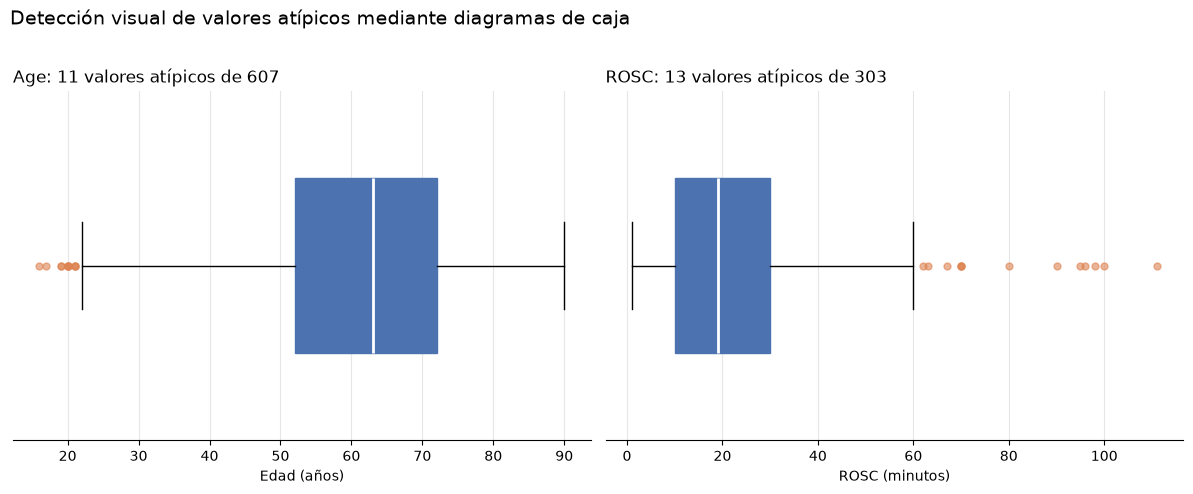

In [46]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, col, etiqueta in [(ax1, 'Age', 'Edad (años)'), (ax2, 'ROSC', 'ROSC (minutos)')]:
    s = clinical_df[col].dropna()
    bp = ax.boxplot(s, vert=False, widths=0.5, patch_artist=True,
                    flierprops=dict(marker='o', markerfacecolor='#DD8452',
                                    markeredgecolor='#DD8452', markersize=5, alpha=0.6))
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][0].set_edgecolor('#4C72B0')
    bp['medians'][0].set_color('white')
    bp['medians'][0].set_linewidth(2)

    _, _, _, inf, sup = limites_iqr(s)
    n_out = int(((s < inf) | (s > sup)).sum())

    ax.set_title(f'{col}: {n_out} valores atípicos de {len(s)}', fontsize=12, loc='left')
    ax.set_xlabel(etiqueta)
    ax.set_yticks([])
    ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ('top', 'right', 'left'):
        ax.spines[lado].set_visible(False)

fig.suptitle('Detección visual de valores atípicos mediante diagramas de caja',
             fontsize=13.5, x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.show()

**Resultados de la detección**

| Variable | n con dato | Q1 | Q3 | Límites IQR | Atípicos | % |
|---|---|---|---|---|---|---|
| `Age` | 607 | 52 | 72 | [22, 102] | 11 (todos bajos) | 1.8% |
| `ROSC` | 303 | 10 | 30 | [-20, 60] | 13 (todos altos) | 4.3% |

En `Age` los 11 valores atípicos corresponden a pacientes jóvenes de 16, 17, 19, 20 y 21 años, y no se detecta ninguno en el extremo superior. En `ROSC` los 13 atípicos son reanimaciones prolongadas de entre 62 y 111 minutos, sin ningún valor atípico por debajo.

**Dos limitaciones del criterio estadístico que conviene señalar**

El criterio del rango intercuartílico es un procedimiento puramente mecánico que desconoce el significado de la variable, y en este conjunto de datos eso se manifiesta de dos formas.

La primera es que para `ROSC` calcula un límite inferior de -20 minutos, un valor físicamente imposible tratándose de una medida de tiempo. El criterio no puede detectar valores anormalmente bajos en esta variable porque su umbral queda fuera del dominio de lo posible.

La segunda es más relevante. Para `Age` el límite superior se sitúa en 102 años, de modo que el valor 90 queda dentro del rango considerado normal y no es señalado como atípico. Sin embargo, al examinar la distribución en el extremo superior se observa una discontinuidad: los conteos descienden progresivamente (87 años: 3 pacientes, 88 años: 2, 89 años: 1) y a continuación repuntan a 7 pacientes en 90 años. Esta interrupción de la tendencia es consistente con la censura por anonimización documentada por los autores del conjunto, según la cual todo paciente mayor de 89 años se registra con edad 90. Se trata por lo tanto de la anomalía más significativa de la variable, y ningún método automático de detección la habría identificado: su reconocimiento depende del conocimiento de la documentación de la fuente.

In [47]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

# A. La censura en 90 años: una anomalía que el criterio estadístico no detecta
print("Pacientes en los valores más altos de Age:")
print(clinical_df['Age'].value_counts().sort_index(ascending=False).head(8).to_string())

_, _, _, inf_age, sup_age = limites_iqr(clinical_df['Age'].dropna())
print(f"\nLímite superior del criterio IQR para Age: {sup_age:.1f} años")
print("El valor 90 NO es detectado como atípico por este criterio, "
      "pese a ser la anomalía más relevante de la variable.\n")

# B. ¿Los atípicos de ROSC son errores o información clínica válida?
_, _, _, _, sup_rosc = limites_iqr(clinical_df['ROSC'].dropna())
es_outlier = clinical_df['ROSC'] > sup_rosc
es_normal = clinical_df['ROSC'].notna() & ~es_outlier

comparacion = pd.DataFrame({
    'n': [int(es_outlier.sum()), int(es_normal.sum())],
    '% Good': [
        (clinical_df.loc[es_outlier, 'Outcome'] == 'Good').mean() * 100,
        (clinical_df.loc[es_normal, 'Outcome'] == 'Good').mean() * 100,
    ],
}, index=[f'ROSC atípico (> {sup_rosc:.0f} min)',
          f'ROSC normal (<= {sup_rosc:.0f} min)']).round(1)

print("Desenlace de los pacientes con ROSC atípico frente al resto:")
print(comparacion.to_string())

# C. Lo mismo para los pacientes jóvenes de Age
es_joven = clinical_df['Age'] < inf_age
print(f"\nPacientes con Age por debajo de {inf_age:.0f} años: {int(es_joven.sum())}")
print(f"  % con desenlace Good: "
      f"{(clinical_df.loc[es_joven, 'Outcome'] == 'Good').mean()*100:.1f}%")
print(f"  Edades registradas: {[int(v) for v in sorted(clinical_df.loc[es_joven, 'Age'].unique())]}")

Pacientes en los valores más altos de Age:
Age
90.0    7
89.0    1
88.0    2
87.0    3
86.0    3
85.0    7
84.0    4
83.0    9

Límite superior del criterio IQR para Age: 102.0 años
El valor 90 NO es detectado como atípico por este criterio, pese a ser la anomalía más relevante de la variable.

Desenlace de los pacientes con ROSC atípico frente al resto:
                           n  % Good
ROSC atípico (> 60 min)   13    15.4
ROSC normal (<= 60 min)  290    28.6

Pacientes con Age por debajo de 22 años: 11
  % con desenlace Good: 27.3%
  Edades registradas: [16, 17, 19, 20, 21]


**Naturaleza de los valores detectados**

Los atípicos de `ROSC` corresponden a reanimaciones cardiopulmonares prolongadas, un evento clínico infrecuente pero perfectamente documentado en la práctica médica. Todos los valores se encuentran dentro del rango fisiológicamente posible y no presentan indicios de error de captura, como valores negativos, ceros o magnitudes imposibles. Al comparar su desenlace con el del resto de pacientes con dato disponible, los casos atípicos presentan 15.4% de desenlaces favorables frente a 28.6% de los demás, una diferencia coherente con el mecanismo clínico, dado que una mayor duración sin circulación implica mayor daño neurológico por isquemia. Debe precisarse que ese 15.4% se calcula sobre 13 pacientes, por lo que la magnitud exacta no es estadísticamente robusta, aunque la dirección del efecto sí resulta consistente con lo observado en la Fase 2.

Los atípicos de `Age` corresponden a pacientes de entre 16 y 21 años. El paro cardíaco en población joven es infrecuente pero real, y estas edades son plenamente plausibles. Su tasa de desenlace favorable es de 27.3%, calculada sobre 11 pacientes, cifra demasiado pequeña para extraer conclusiones.

El caso de los 7 pacientes registrados con 90 años es distinto de los anteriores: no es un error de medición ni un valor excepcional, sino un valor censurado en origen. Su edad real es desconocida y únicamente se sabe que es igual o superior a 90 años.

---

**¿Son errores de medición o representan información válida pero excepcional?**

Son información válida pero excepcional. Ninguno de los 24 valores atípicos detectados presenta características de error de captura: todos se encuentran dentro del rango fisiológicamente posible y resultan clínicamente coherentes. Las reanimaciones prolongadas y los paros cardíacos en pacientes jóvenes son eventos poco frecuentes, pero reales y documentados. El único valor que no corresponde a un dato observado directamente es la edad de 90 años, que es un valor censurado por anonimización y no un error.

**¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?**

Se aplicó el criterio del rango intercuartílico, que clasifica como atípico todo valor situado a más de 1.5 veces el IQR por debajo del primer cuartil o por encima del tercero. Este criterio se complementó con el conocimiento de la documentación oficial del conjunto de datos, que fue lo que permitió identificar la censura de la edad en 90 años, anomalía que el criterio estadístico no detecta.

**¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?**

Ambos. El método estadístico fue el criterio IQR descrito, y el visual fueron los diagramas de caja elaborados para `Age` y `ROSC`, que permiten apreciar simultáneamente la forma de la distribución y la ubicación de los valores extremos. Los diagramas confirman lo que indica el cálculo: `Age` presenta su dispersión en el extremo inferior y `ROSC` una cola prolongada hacia la derecha.

**¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?**

Se decidió **conservar la totalidad de los valores atípicos, sin eliminarlos ni transformarlos**, por dos razones.

La primera es que no son errores. Eliminar o recortar valores válidos equivale a descartar información real del fenómeno estudiado.

La segunda es que son los casos con mayor contenido informativo del conjunto. El objetivo del proyecto es caracterizar la relación entre las variables clínicas y el desenlace neurológico, y los pacientes con reanimaciones prolongadas son precisamente los que expresan con mayor claridad esa relación. Eliminarlos suprimiría la evidencia más fuerte disponible sobre el efecto del tiempo de reanimación.

Respecto a la censura de la edad en 90 años, no procede ningún tratamiento correctivo, dado que los valores reales fueron eliminados en la fuente por razones de anonimización y no pueden recuperarse. La decisión consiste en documentarla explícitamente, de modo que cualquier análisis posterior que involucre la edad en el extremo superior de la distribución considere que esos 7 registros representan un límite inferior y no una edad exacta.

### **1.4. Datos Inconsistentes**
---
Frente a inconsistencias en los datos, es importante analizar cómo estas discrepancias podrían afectar la comparabilidad y comprensión de la información.

* ¿Cómo se identificaron las inconsistencias en los datos?
* ¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?
* ¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?
* ¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?
* ¿Se establecieron reglas de validación específicas para garantizar la consistencia?

# 1.3 - 1.6 - Preparación de Datos
---

Proyecto ICARE - CRISP-DM


1. **1.4. Datos inconsistentes** — homogeneización de tipos, formatos y categorías.
2. **1.5. Datos corruptos** — validación de rangos clínicos y reglas de coherencia.
3. **1.6. Selección de datos** — criterios de inclusión/exclusión de variables y registros.

**Alcance de este notebook:** se trabaja sobre los **metadatos clínicos**
(`icare_clinical_data.csv`), que están disponibles localmente y permiten un
análisis reproducible sin depender de descargas remotas. Los registros
fisiológicos (EEG/ECG), documentados en `02_understanding_data`, representan
36.123 archivos alojados en PhysioNet y su preparación (segmentación, filtrado
de señal, extracción de características) se abordará en un notebook posterior
dedicado exclusivamente a esa modalidad, dado su volumen y naturaleza distinta.

## 0. Configuración del entorno
---

In [44]:
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_OK = "#4C72B0"
COLOR_BAD = "#DD8452"
COLOR_NEUTRAL = "#8C8C8C"

In [46]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".git").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Directorio de salida:", PROCESSED_DIR)

Project root: C:\Users\dellphoto\mlda-project_alejandra
Directorio de salida: C:\Users\dellphoto\mlda-project_alejandra\data\processed


### Carga de los datos crudos

Se reutiliza `clinical_df`, ya
descargado y construido al inicio de este mismo notebook a partir de
PhysioNet. Sus columnas llegan como texto (`str`) porque se construyeron a
partir del parseo linea a linea de los archivos `.txt` de cada paciente, sin
ninguna conversion de tipos todavia. Este es el mismo estado "sin tipificar"
descrito en `02_understanding_data`, y es el punto de partida real sobre el
que debe actuar la fase de preparacion.

In [47]:
clinical_raw = clinical_df.copy()

print("Dimensiones:", clinical_raw.shape)
clinical_raw.dtypes.value_counts()

Dimensiones: (607, 13)


str         7
float64     3
object      2
category    1
Name: count, dtype: int64

In [48]:
clinical_raw.head()

,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC,ROSC_cat,TTM_grupo,TTM_cat
0,0284,A,53.0,Male,NaN,True,True,33.0,Good,1,Sin dato,33 °C,33 °C
1,0286,F,85.0,Female,7.0,False,False,NaN,Good,1,Rápido (1-10 min),Sin TTM,Sin TTM
2,0296,A,48.0,Male,NaN,True,True,36.0,Good,1,Sin dato,36 °C,36 °C
3,0299,A,45.0,Male,NaN,True,True,33.0,Good,1,Sin dato,33 °C,33 °C
4,0303,D,51.0,Male,24.0,True,True,33.0,Good,1,Intermedio (11-30 min),33 °C,33 °C


## 1.4. Datos Inconsistentes
---
Frente a inconsistencias en los datos, es importante analizar cómo estas discrepancias podrían afectar la comparabilidad y comprensión de la información.

* ¿Cómo se identificaron las inconsistencias en los datos?
* ¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?
* ¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?
* ¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?
* ¿Se establecieron reglas de validación específicas para garantizar la consistencia?

### 1.4.1 Identificación de inconsistencias

Siguiendo el mismo procedimiento sistemático usado en `02_understanding_data`,
se revisan cuatro fuentes típicas de inconsistencia:

1. **Tipificación:** columnas conceptualmente numéricas o booleanas almacenadas como texto.
2. **Codificación de valores faltantes:** ¿todas las columnas usan un único marcador de "faltante"?
3. **Diversidad de categorías:** ¿los valores únicos de cada variable categórica corresponden a un conjunto cerrado y documentado?
4. **Coherencia cruzada:** ¿variables relacionadas entre sí (`CPC` y `Outcome`) son consistentes entre ellas?

In [65]:
# 1. Tipificación: todas las columnas llegan como texto (object/str)
print("Tipos de dato al cargar:")
print(clinical_raw.dtypes)

Tipos de dato al cargar:
Patient                  str
Hospital                 str
Age                  float64
Sex                      str
ROSC                 float64
OHCA                  object
Shockable Rhythm      object
TTM                  float64
Outcome                  str
CPC                      str
ROSC_cat            category
TTM_grupo                str
TTM_cat                  str
dtype: object


In [50]:
# 2. Codificación de valores faltantes: ¿queda algún "nan" como texto literal
#    tras la carga, en vez de un NaN real de pandas?
literal_nan_counts = (clinical_raw == "nan").sum()
literal_nan_counts = literal_nan_counts[literal_nan_counts > 0]

print("Columnas con el string literal 'nan' tras la carga:")
print(literal_nan_counts if len(literal_nan_counts) else "Ninguna")

print("\nValores nulos reales detectados por pandas al cargar:")
print(clinical_raw.isna().sum())

Columnas con el string literal 'nan' tras la carga:
Ninguna

Valores nulos reales detectados por pandas al cargar:
Patient               0
Hospital              0
Age                   0
Sex                   3
ROSC                304
OHCA                  0
Shockable Rhythm      0
TTM                  98
Outcome               0
CPC                   0
ROSC_cat              0
TTM_grupo             0
TTM_cat               0
dtype: int64


No queda ningún `"nan"` como texto literal: `pandas.read_csv` reconoce por
defecto la cadena `"nan"` como valor faltante (forma parte de su lista interna
de *na_values*) y la convierte a `NaN` real incluso forzando `dtype=str`. Esto
confirma que el problema de "faltantes ocultos" detectado en `02_understanding_data`
era propio del **proceso de adquisición** (construcción manual del CSV a
partir de los archivos `.txt` de PhysioNet) y no reaparece al leer el archivo
ya persistido. Aun así, la verificación explícita se mantiene como una regla
de calidad permanente: cualquier futura re-adquisición de los datos debe
pasar por esta misma comprobación antes de continuar.

In [66]:
# 3. Diversidad de categorías: VALORES UNICOS por variable categórica/booleana
categorical_like = ["Hospital", "Sex", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]

for col in categorical_like:
    print(f"{col:18s} -> {sorted(clinical_raw[col].dropna().unique())}")

Hospital           -> ['A', 'B', 'D', 'E', 'F']
Sex                -> ['Female', 'Male']
OHCA               -> ['Desconocido', 'False', 'True']
Shockable Rhythm   -> ['Desconocido', 'False', 'True']
Outcome            -> ['Good', 'Poor']
CPC                -> ['1', '2', '3', '4', '5']


**Hallazgos de inconsistencia:**

- `Age`, `ROSC`, `TTM`, `CPC`: variables conceptualmente numéricas, almacenadas como texto.
- `OHCA`, `Shockable Rhythm`: variables conceptualmente booleanas, almacenadas como los textos `"True"`/`"False"` en vez de un tipo booleano nativo.
- `Hospital`: usa códigos de una sola letra (`A`, `B`, `D`, `E`, `F`); **no existe el código `C`**, ya que el consorcio original tenía 7 sitios y el conjunto público de entrenamiento solo incluye 6. No es un error de captura, pero es una inconsistencia frente a la documentación del estudio si no se deja explícita.
- `TTM`: numéricamente solo toma los valores `33` y `36`, comportándose como una variable **categórica ordinal** disfrazada de continua.

In [52]:
# 4. Coherencia cruzada entre CPC y Outcome
cpc_to_outcome = {1: "Good", 2: "Good", 3: "Poor", 4: "Poor", 5: "Poor"}

cpc_numeric = pd.to_numeric(clinical_raw["CPC"], errors="coerce")
expected_outcome = cpc_numeric.map(cpc_to_outcome)
mismatches = (expected_outcome != clinical_raw["Outcome"]).sum()

print("Escala clínica CPC -> Outcome esperado:", cpc_to_outcome)
print("Registros donde Outcome no coincide con el mapeo esperado de CPC:", mismatches)

Escala clínica CPC -> Outcome esperado: {1: 'Good', 2: 'Good', 3: 'Poor', 4: 'Poor', 5: 'Poor'}
Registros donde Outcome no coincide con el mapeo esperado de CPC: 0


No se encontraron inconsistencias entre `CPC` y `Outcome`: la variable objetivo
fue construida correctamente a partir de la escala clínica CPC en los 607
registros. Esta comprobación es igualmente una **regla de validación cruzada**
que se conserva para reejecutarse ante cualquier actualización del dataset.

### 1.4.2 ¿Se justifica la estandarización?

Sí. Aunque ninguna inconsistencia corresponde a un error de captura grave, **todas
afectan directamente la comparabilidad y el uso posterior de los datos**:

- Sin conversión de tipos, no es posible calcular estadísticas, graficar ni
  usar estas columnas como entrada de un modelo.
- Sin una representación booleana nativa, cualquier operación lógica u
  operación aritmética sobre `OHCA`/`Shockable Rhythm` falla o produce
  resultados incorrectos (como se documentó en `02_understanding_data`, al
  intentar `.astype(int)` directamente sobre el texto `"True"`).
- Sin dejar explícita la ausencia del hospital `C`, un análisis por sitio
  podría interpretarse erróneamente como que hay 7 sitios representados.
- Sin reconocer a `TTM` como pseudo-categórica, un modelo podría tratarla
  como una escala continua con una relación lineal inexistente.

Por lo tanto, la estandarización no es opcional: es un requisito para que el
resto del pipeline (EDA cuantitativo, modelado) sea correcto.

### 1.4.3 Homogeneización de unidades y formatos

Se define un esquema de tipos y categorías único y documentado:

| Columna | Tipo original | Tipo estandarizado | Regla |
|---|---|---|---|
| `Age` | texto | `float64` | años, rango clínico plausible 0-120 |
| `ROSC` | texto | `float64` | minutos, `>= 0` |
| `TTM` | texto | `float64` (+ vista categórica) | grados Celsius, dominio cerrado `{33, 36}` |
| `CPC` | texto | `Int64` (entero, admite `NA`) | escala ordinal 1-5 |
| `OHCA` | texto `"True"`/`"False"` | `boolean` (booleano nullable de pandas) | preserva `NA` reales |
| `Shockable Rhythm` | texto `"True"`/`"False"` | `boolean` | preserva `NA` reales |
| `Hospital` | texto | `category` | dominio cerrado `{A, B, D, E, F}` |
| `Sex` | texto | `category` | dominio cerrado `{Male, Female}` |
| `Outcome` | texto | `category` (ordenada) | dominio cerrado `{Good, Poor}` |

In [53]:
def standardize_clinical(df_raw: pd.DataFrame) -> pd.DataFrame:
    '''Aplica el esquema de tipos y categorías homogéneo descrito arriba.'''
    df = df_raw.copy()

    # Numéricas continuas / discretas
    for col in ["Age", "ROSC", "TTM"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["CPC"] = pd.to_numeric(df["CPC"], errors="coerce").astype("Int64")

    # Booleanas nativas (nullable), en vez de texto "True"/"False"
    bool_map = {"True": True, "False": False}
    for col in ["OHCA", "Shockable Rhythm"]:
        df[col] = df[col].map(bool_map).astype("boolean")

    # Categóricas de dominio cerrado
    df["Hospital"] = pd.Categorical(df["Hospital"], categories=["A", "B", "D", "E", "F"])
    df["Sex"] = pd.Categorical(df["Sex"], categories=["Male", "Female"])
    df["Outcome"] = pd.Categorical(df["Outcome"], categories=["Good", "Poor"], ordered=False)

    return df


clinical_std = standardize_clinical(clinical_raw)
clinical_std.dtypes

Patient                  str
Hospital            category
Age                  float64
Sex                 category
ROSC                 float64
OHCA                 boolean
Shockable Rhythm     boolean
TTM                  float64
Outcome             category
CPC                    Int64
ROSC_cat            category
TTM_grupo                str
TTM_cat                  str
dtype: object

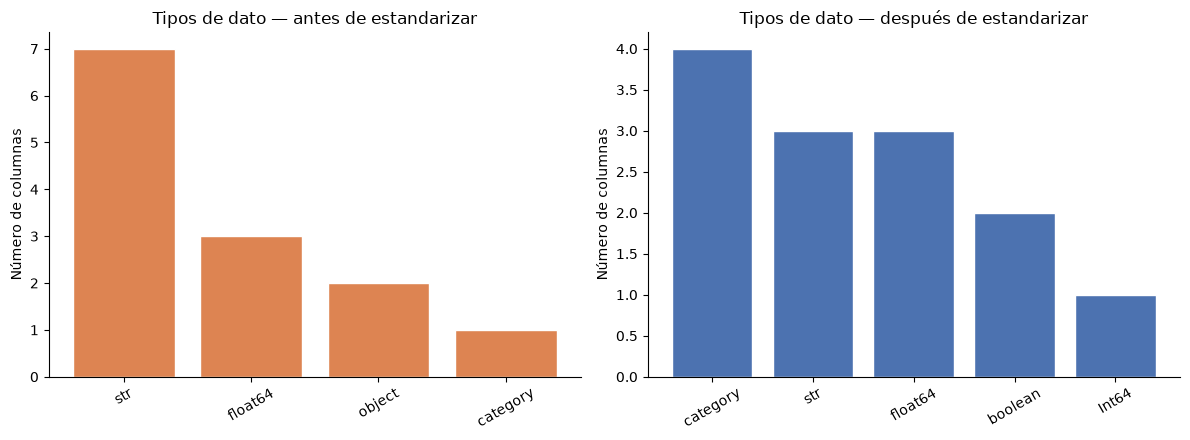

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

tipo_antes = clinical_raw.dtypes.astype(str).value_counts()
tipo_despues = clinical_std.dtypes.astype(str).value_counts()

axes[0].bar(tipo_antes.index, tipo_antes.values, color=COLOR_BAD, edgecolor="white")
axes[0].set_title("Tipos de dato — antes de estandarizar")
axes[0].set_ylabel("Número de columnas")

axes[1].bar(tipo_despues.index, tipo_despues.values, color=COLOR_OK, edgecolor="white")
axes[1].set_title("Tipos de dato — después de estandarizar")
axes[1].set_ylabel("Número de columnas")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Antes de la estandarización, las 10 columnas comparten un único tipo (`object`/texto),
lo que oculta por completo la naturaleza real de cada variable. Después, el
dataset queda repartido en 5 tipos distintos (`float64`, `Int64`, `boolean`,
`category`), cada uno alineado con el significado clínico de la variable
correspondiente.

### 1.4.4 Estrategias implementadas

1. **Conversión explícita de tipos** (`pd.to_numeric`, `.astype("Int64")`, `.astype("boolean")`)
   en vez de depender de la inferencia automática de pandas, evitando conversiones
   silenciosas incorrectas.
2. **Mapeo explícito para booleanos** (`{"True": True, "False": False}`) en lugar de
   una conversión directa, que es justamente la operación que fallaba en el
   notebook de entendimiento de datos.
3. **Tipos categóricos con dominio cerrado** (`pd.Categorical(..., categories=[...])`):
   cualquier valor fuera del dominio declarado se convierte automáticamente en
   `NaN` y queda visible como valor faltante en vez de pasar desapercibido como
   una categoría nueva no documentada.
4. **Función reutilizable** (`standardize_clinical`) en vez de transformaciones
   sueltas, de modo que el mismo criterio se pueda reaplicar de forma idéntica
   si el dataset se vuelve a descargar o se actualiza.

### 1.4.5 Reglas de validación establecidas

Se implementa una función de validación que encapsula las reglas de dominio
descritas en la tabla anterior y reporta cualquier violación encontrada.

In [55]:
def validate_clinical(df: pd.DataFrame) -> pd.DataFrame:
    '''Ejecuta reglas de consistencia sobre el dataset ya estandarizado y
    devuelve un resumen con el número de violaciones por regla.'''
    checks = {
        "Age fuera de [0, 120]": ((df["Age"] < 0) | (df["Age"] > 120)).sum(),
        "ROSC negativo": (df["ROSC"] < 0).sum(),
        "TTM fuera de {33, 36}": (df["TTM"].notna() & ~df["TTM"].isin([33, 36])).sum(),
        "CPC fuera de [1, 5]": (df["CPC"].notna() & ~df["CPC"].isin([1, 2, 3, 4, 5])).sum(),
        "Hospital fuera de dominio": df["Hospital"].isna().sum() - clinical_raw["Hospital"].isna().sum(),
        "Patient ID duplicado": df["Patient"].duplicated().sum(),
    }
    return pd.DataFrame.from_dict(checks, orient="index", columns=["Violaciones"])


validation_report = validate_clinical(clinical_std)
validation_report

,Violaciones
"Age fuera de [0, 120]",0
ROSC negativo,0
"TTM fuera de {33, 36}",0
"CPC fuera de [1, 5]",0
Hospital fuera de dominio,0
Patient ID duplicado,0


Todas las reglas reportan **cero violaciones**: la estandarización de tipos y
categorías no introdujo pérdida de información (ningún valor de `Hospital`
quedó fuera del dominio declarado) y los rangos clínicos se cumplen en la
totalidad de los 607 registros. Estas reglas quedan encapsuladas en
`validate_clinical()` para poder ejecutarse automáticamente cada vez que el
dataset se actualice, sin depender de una revisión manual repetida.

## 1.5. Datos corruptos
---
En la detección de datos corruptos, pregunte si hay posibles errores de entrada o problemas de transferencia que podrían haber afectado la integridad de los datos.
* ¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?
* ¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?
* ¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?

### 1.5.1 Cómo se determinó la presencia de datos corruptos

Se distingue explícitamente **inconsistencia de formato** (sección 1.4, ya
resuelta) de **corrupción de datos**: un dato corrupto es un valor que,
aunque bien tipificado, es clínicamente imposible o contradice otra variable
relacionada. Se aplican dos mecanismos:

1. **Validación de rango clínico** por variable (ya definidos como reglas en
   `validate_clinical`, reutilizadas aquí con foco en integridad más que en
   formato).
2. **Validación de coherencia cruzada** entre variables relacionadas
   (`CPC` ↔ `Outcome`) y de unicidad de identificadores (`Patient`).

Adicionalmente se inspecciona visualmente la distribución de las variables
numéricas para detectar valores extremos que las reglas de rango, por ser
amplias, no capturarían (p. ej. una edad de 45 años es válida, pero podría ser
producto de un error de transcripción si el resto de la evidencia clínica no
es coherente).

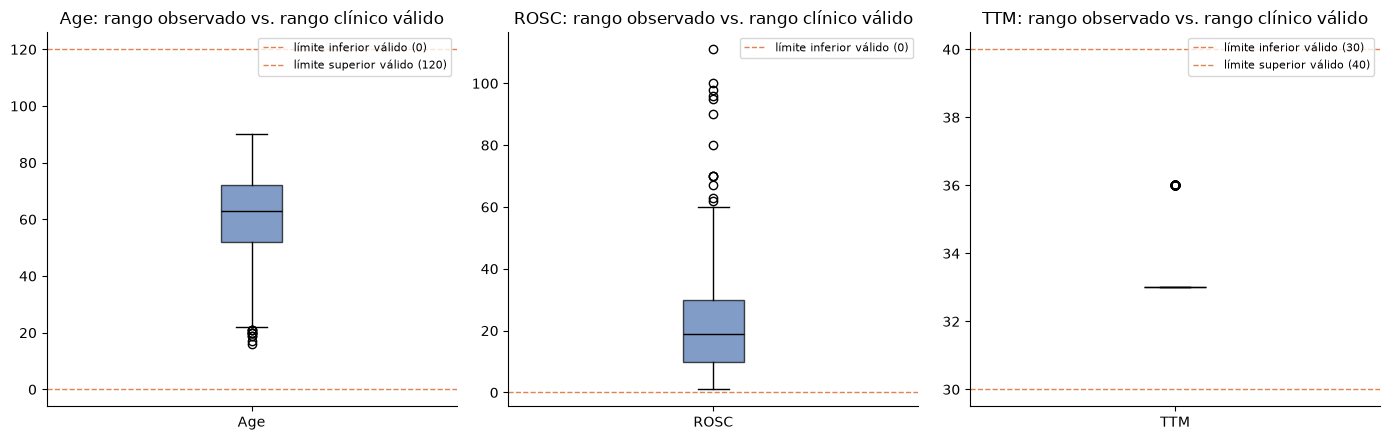

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

rangos_validos = {"Age": (0, 120), "ROSC": (0, None), "TTM": (30, 40)}

for ax, (col, (low, high)) in zip(axes, rangos_validos.items()):
    data = clinical_std[col].dropna()
    bp = ax.boxplot(data, tick_labels=[col], patch_artist=True,
                     medianprops=dict(color="black"))
    for box in bp["boxes"]:
        box.set_facecolor(COLOR_OK)
        box.set_alpha(0.7)

    ax.axhline(low, color=COLOR_BAD, linestyle="--", linewidth=1,
                label=f"límite inferior válido ({low})")
    if high is not None:
        ax.axhline(high, color=COLOR_BAD, linestyle="--", linewidth=1,
                    label=f"límite superior válido ({high})")

    ax.set_title(f"{col}: rango observado vs. rango clínico válido")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

En los tres casos, toda la distribución observada (incluyendo los valores
más extremos, ya caracterizados como outliers estadísticos en
`02_understanding_data`) cae **dentro** del rango clínicamente plausible: no
hay evidencia visual de valores imposibles.

In [57]:
integrity_checks = {
    "CPC/Outcome inconsistentes": int(
        (cpc_numeric.map(cpc_to_outcome) != clinical_raw["Outcome"]).sum()
    ),
    "Patient ID duplicado": int(clinical_std["Patient"].duplicated().sum()),
    "Registro (fila) completamente duplicado": int(clinical_std.duplicated().sum()),
    "Age fuera de [0, 120]": int(((clinical_std["Age"] < 0) | (clinical_std["Age"] > 120)).sum()),
    "ROSC negativo": int((clinical_std["ROSC"] < 0).sum()),
    "TTM fuera de {33, 36}": int(
        (clinical_std["TTM"].notna() & ~clinical_std["TTM"].isin([33, 36])).sum()
    ),
}

integrity_df = pd.Series(integrity_checks, name="Casos detectados").to_frame()
integrity_df

,Casos detectados
CPC/Outcome inconsistentes,0
Patient ID duplicado,0
Registro (fila) completamente duplicado,0
"Age fuera de [0, 120]",0
ROSC negativo,0
"TTM fuera de {33, 36}",0


### 1.5.2 Medidas tomadas

**No se encontró evidencia de datos corruptos** en `icare_clinical_data.csv`:
cero inconsistencias CPC/Outcome, cero duplicados (ni por `Patient` ni por
fila completa) y cero valores fuera de rango clínico en `Age`, `ROSC` o `TTM`.
En consecuencia, **no fue necesario corregir ni eliminar ningún registro**.

El trabajo se enfoco en **construir el mecanismo de detección**
(`integrity_checks`) que permite afirmar esto con evidencia reproducible, y
que se debe reejecutar ante cualquier actualización del dataset o
incorporación de nuevos pacientes.

### 1.5.3 Casos que no se pudieron (ni debieron) "corregir"

Dos hallazgos de `02_understanding_data` podrían confundirse con corrupción,
pero se decidió **dejarlos intactos**, con la siguiente justificación:

- **Acumulación anómala de pacientes en `Age = 90`.** Es consistente con una
  práctica común de *top-coding*/censura de edad (agrupar "90 años o más" en
  el valor 90) para proteger la identidad de pacientes muy longevos, no con
  un error de transcripción. "Corregir" este valor inventaría una edad exacta
  que el dataset nunca tuvo — sería introducir información falsa, no corregir
  un dato corrupto.
- **Valores faltantes estructurales en `ROSC` (50.1%) y `TTM` (16.1%).**
  No son errores de transferencia: un paciente sin `ROSC` registrado
  corresponde a un paro cardíaco con retorno de circulación no documentado
  como espontáneo, y un `TTM` faltante corresponde a un paciente que no
  recibió manejo de temperatura dirigido. Imputar estos valores en esta etapa
  reemplazaría una ausencia clínicamente informativa por un valor inventado,
  y esa decisión de imputación (si se toma) debe quedar ligada al modelo que
  la consuma, no a la fase de preparación general de datos. Por eso se
  conservan como `NaN` explícitos y trazables.

En ambos casos, la decisión de no intervenir está documentada aquí para que
cualquier persona que continúe el proyecto entienda que es una decisión
deliberada, no un descuido.

## 1.6. Selección de datos
---
En la selección de datos, reflexione sobre las variables que son realmente relevantes para sus objetivos de análisis.
* ¿Qué criterios se utilizaron para seleccionar los datos relevantes para el análisis?
* ¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto de datos?
* ¿Cómo se justificó la inclusión o exclusión de ciertas variables en la selección de datos?

### 1.6.1 Criterios de selección de variables

Cada una de las 10 columnas del dataset se clasifica según su **rol** dentro
del objetivo del proyecto (predecir `Outcome`, el desenlace neurológico del
paciente), aplicando tres criterios:

1. **Relevancia clínica/predictiva:** ¿la variable aporta información
   plausible sobre el desenlace, según la literatura y el análisis de
   correlación de `02_understanding_data`?
2. **Riesgo de fuga de información (*data leakage*):** ¿la variable fue usada
   para construir la variable objetivo, o solo estaría disponible *después*
   de conocer el desenlace?
3. **Calidad/completitud:** ¿el nivel de valores faltantes es manejable, o
   compromete el uso de la variable?

In [59]:
variable_roles = pd.DataFrame([
    {"Variable": "Patient", "Rol": "Identificador", "Motivo": "Único por paciente; se usa como índice, no como feature."},
    {"Variable": "Hospital", "Rol": "Feature", "Motivo": "Posible proxy de protocolo clínico/heterogeneidad de sitio."},
    {"Variable": "Age", "Rol": "Feature", "Motivo": "Relevancia clínica y asociación con Outcome ya evidenciada."},
    {"Variable": "Sex", "Rol": "Feature", "Motivo": "Variable demográfica estándar, bajo % de faltantes (0.49%)."},
    {"Variable": "ROSC", "Rol": "Feature", "Motivo": "Relevancia clínica alta pese a 50% de faltantes (missingness informativo)."},
    {"Variable": "OHCA", "Rol": "Feature", "Motivo": "Contexto del paro cardíaco, relevante clínicamente."},
    {"Variable": "Shockable Rhythm", "Rol": "Feature", "Motivo": "Mayor correlación con Outcome de toda la matriz extendida (-0.37)."},
    {"Variable": "TTM", "Rol": "Feature", "Motivo": "Refleja tratamiento recibido; ausencia también es informativa."},
    {"Variable": "Outcome", "Rol": "Target", "Motivo": "Variable objetivo del proyecto."},
    {"Variable": "CPC", "Rol": "Excluida (leakage)", "Motivo": "Es la escala clínica a partir de la cual se deriva Outcome de forma determinista; incluirla como feature filtraría la respuesta al modelo."},
]).set_index("Variable")

variable_roles

,Rol,Motivo
Variable,,
Patient,Identificador,"Único por paciente; se usa como índice, no com..."
Hospital,Feature,Posible proxy de protocolo clínico/heterogenei...
Age,Feature,Relevancia clínica y asociación con Outcome ya...
Sex,Feature,"Variable demográfica estándar, bajo % de falta..."
ROSC,Feature,Relevancia clínica alta pese a 50% de faltante...
OHCA,Feature,"Contexto del paro cardíaco, relevante clínicam..."
Shockable Rhythm,Feature,Mayor correlación con Outcome de toda la matri...
TTM,Feature,Refleja tratamiento recibido; ausencia también...
Outcome,Target,Variable objetivo del proyecto.


El hallazgo más importante de esta sección es la exclusión de `CPC`: en
`02_understanding_data` se verificó que `Outcome` se deriva **exactamente**
de `CPC` mediante una regla determinista (`CPC` 1-2 → `Good`, `CPC` 3-5 →
`Poor`). Si `CPC` se incluyera como variable predictora, cualquier modelo
alcanzaría una precisión artificialmente perfecta sin haber aprendido ninguna
relación clínica real — un caso clásico de *data leakage*. `CPC` se conserva
en un dataframe de referencia separado (útil, por ejemplo, para auditar el
propio proceso de construcción de `Outcome`), pero **no entra al conjunto de
variables de entrada**.

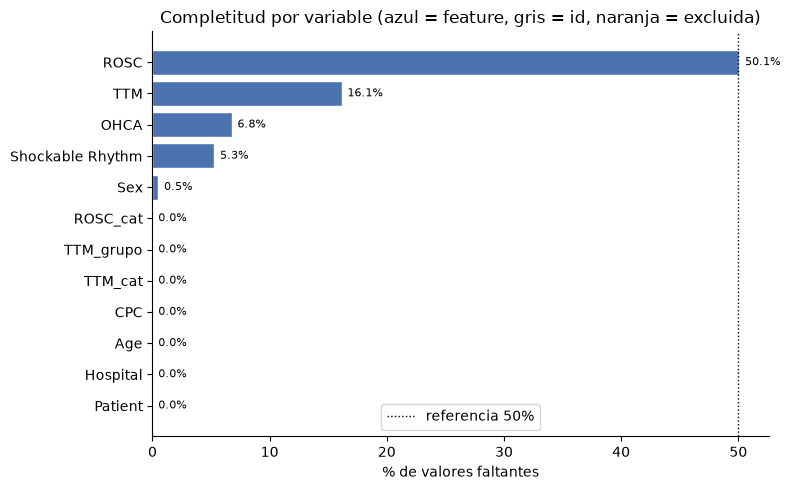

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

missing_pct = (clinical_std.isna().mean() * 100).drop(["Outcome"]).sort_values()
role_colors = {
    "Patient": COLOR_NEUTRAL,
    "CPC": COLOR_BAD,
}
colors = [role_colors.get(col, COLOR_OK) for col in missing_pct.index]

ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor="white")
ax.axvline(50, color="black", linestyle=":", linewidth=1, label="referencia 50%")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Completitud por variable (azul = feature, gris = id, naranja = excluida)")
ax.legend()

for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Aunque `ROSC` supera el umbral de referencia del 50% de faltantes, se decide
**mantenerla como feature** en esta fase (en vez de descartarla por
completitud) porque:

- Su ausencia es estructuralmente informativa (ver 1.5.3), no aleatoria.
- Es, junto con `Shockable Rhythm`, una de las variables con relación más
  clara al desenlace observada en el análisis de correlación.
- Descartarla ahora cerraría opciones de modelado (p. ej. uso de un
  indicador de faltante, o modelos tolerantes a `NaN`) que corresponden a
  decisiones de la fase de modelado, no de esta fase de preparación general.

El único caso en el que la completitud sí determina una exclusión directa es
`Patient`, pero por su rol de identificador, no por su calidad.

### 1.6.2 Muestreo o filtrado de registros

**No se aplicó ninguna técnica de muestreo ni filtrado de filas.** Se
conservan los 607 pacientes en su totalidad. Justificación:

- El archivo `icare_clinical_data.csv` **ya es** el conjunto público de
  entrenamiento completo de I-CARE v2.1 (no una muestra más grande de la que
  convenga extraer un subconjunto); no hay una población mayor disponible
  localmente de la cual muestrear.
- El tamaño muestral (607) ya es moderado para tareas de clasificación
  clínica; reducirlo aún más perjudicaría la potencia estadística sin
  ningún beneficio de calidad, dado que en 1.5 se confirmó la ausencia de
  registros corruptos o duplicados que justificaran eliminarlos.
- Eliminar filas con valores faltantes (p. ej. en `ROSC` o `TTM`) introduciría
  sesgo: como se documentó en `02_understanding_data`, la falta de `TTM` está
  concentrada en pacientes que no recibieron manejo de temperatura, por lo
  que un filtrado por completitud alteraría artificialmente la distribución
  por `Hospital` y por `Outcome`.

Se verifica a continuación que, en efecto, el dataframe preparado conserva
los 607 registros.

In [61]:
assert clinical_std.shape[0] == 607, "Se esperaba conservar los 607 pacientes."
print("Registros conservados:", clinical_std.shape[0])

Registros conservados: 607


### 1.6.3 Construcción del dataset preparado

Se construye el dataframe nos ayudara mas adelante, aplicando
las decisiones de esta sección: `Patient` como índice, `CPC` separado en un
dataframe de referencia y el resto de las variables ya estandarizadas (1.4)
como conjunto de *features* + *target*.

In [62]:
feature_cols = ["Hospital", "Age", "Sex", "ROSC", "OHCA", "Shockable Rhythm", "TTM"]

clinical_prepared = (
    clinical_std
    .set_index("Patient")[feature_cols + ["Outcome"]]
)

cpc_reference = clinical_std.set_index("Patient")[["CPC"]]

print("clinical_prepared:", clinical_prepared.shape)
clinical_prepared.head()

clinical_prepared: (607, 8)


,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome
Patient,,,,,,,,
0284,A,53.0,Male,NaN,True,True,33.0,Good
0286,F,85.0,Female,7.0,False,False,NaN,Good
0296,A,48.0,Male,NaN,True,True,36.0,Good
0299,A,45.0,Male,NaN,True,True,33.0,Good
0303,D,51.0,Male,24.0,True,True,33.0,Good


In [63]:
output_path = PROCESSED_DIR / "clinical_prepared.csv"
reference_path = PROCESSED_DIR / "cpc_reference.csv"

clinical_prepared.to_csv(output_path)
cpc_reference.to_csv(reference_path)

print("Guardado:", output_path)
print("Guardado:", reference_path)

Guardado: C:\Users\dellphoto\mlda-project_alejandra\data\processed\clinical_prepared.csv
Guardado: C:\Users\dellphoto\mlda-project_alejandra\data\processed\cpc_reference.csv


### 1.6.4 Resumen de la fase de preparación (metadatos clínicos)

| Aspecto | Antes (02) | Después (03) |
|---|---|---|
| Registros | 607 | 607 (sin filtrado) |
| Columnas | 10, todas `object` | 7 features + 1 target, tipadas y validadas |
| `CPC` | mezclada con las demás variables | separada como referencia, excluida por *leakage* |
| Booleanos | texto `"True"/"False"` | `boolean` nullable |
| Categorías | sin dominio declarado | `category` con dominio cerrado y validado |
| Datos corruptos | no evaluados explícitamente | 0 encontrados, con panel de integridad reproducible |

**Próximos pasos:** la preparación de los registros fisiológicos EEG (que
requiere descarga desde PhysioNet, segmentación por ventanas de tiempo y
extracción de características de señal) se desarrollará en un notebook
independiente, dado el volumen de datos (36.123 registros) y la naturaleza
distinta de su procesamiento frente a los metadatos clínicos aquí preparados.

---**INGRESE SU RESPUESTA**---

In [39]:
# ---INGRESE SU CÓDIGO---

### **1.5. Datos corruptos**
---
En la detección de datos corruptos, pregunte si hay posibles errores de entrada o problemas de transferencia que podrían haber afectado la integridad de los datos.
* ¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?
* ¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?
* ¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?

---**INGRESE SU RESPUESTA**---

In [40]:
# ---INGRESE SU CÓDIGO---

### **1.6. Selección de datos**
---
En la selección de datos, reflexione sobre las variables que son realmente relevantes para sus objetivos de análisis.
* ¿Qué criterios se utilizaron para seleccionar los datos relevantes para el análisis?
* ¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto de datos?
* ¿Cómo se justificó la inclusión o exclusión de ciertas variables en la selección de datos?

---**INGRESE SU RESPUESTA**---

### Preprocesamiento y transformación

In [41]:
# ---INGRESE SU CÓDIGO---

# Records

### Faltantes

### Duplicados

### Atipicos

### Inconsistentes

### Corruptos

### Selección de los datos

### Preprocesamiento y transformación

## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*